In [1]:
# [DÀNH RIÊNG CHO GOOGLE COLAB]
import sys, os
os.environ['MINIO_ENDPOINT'] = 'http://20.41.113.183:9000'
os.environ['MINIO_ACCESS_KEY'] = 'minioadmin'
os.environ['MINIO_SECRET_KEY'] = 'minioadmin123'
if 'SEED_PATH' in os.environ: del os.environ['SEED_PATH']
if 'google.colab' in sys.modules:
    !rm -rf /content/Lab
    !git clone -b feat-e https://github.com/nbngoc123/Lab.git /content/Lab
    os.chdir('/content/Lab/football-lake')
    sys.path.insert(0, '/content/Lab/football-lake')
    !pip install minio duckdb pandas understatapi boto3 python-dotenv
    print('Setup xong Colab!')


Cloning into '/content/Lab'...
remote: Enumerating objects: 825, done.
remote: Counting objects: 100% (310/310), done.
remote: Compressing objects: 100% (193/193), done.
remote: Total 825 (delta 148), reused 213 (delta 72), pack-reused 515 (from 1)
Receiving objects: 100% (825/825), 70.42 MiB | 27.56 MiB/s, done.
Resolving deltas: 100% (379/379), done.
Setup xong Colab!


## 1. Import & Cấu hình

In [2]:
"""
build_features.py — silver -> gold/features (CHỈ tầng feature).

Đặt tại: football-lake/ml/features/build_features.py
Chạy trong container airflow:
    python ml/features/build_features.py                # MinIO
    python ml/features/build_features.py --root ./lake  # thư mục local (thử nghiệm)

ĐỌC silver: matches/fd_matches, odds/fd_odds, teams/understat_team_xg,
            text/wm_pageviews (entity=team), matches/fd_matches_weather (4 nguồn sau là tùy chọn)
GHI gold/features/: feature_team_match, feature_league_position, feature_elo, feature_market,
            feature_team_xg, feature_team_attention, feature_match_context,
            feature_match_ml (1 dòng/trận + target_*), _feature_catalog.csv

CHỐNG RÒ RỈ: feature của trận T chỉ dùng dữ liệu (ngày, match_id) < T.
"""
import argparse, io, os, sys
from pathlib import Path
import duckdb
import pandas as pd
OUT = "gold/features"
SRC_TAG = "gold-features"
ROLL_FEATS = ["n_prior", "n_prior_season", "rest_days",
    "pts_l5", "gf_l5", "ga_l5", "sot_l5", "sot_against_l5", "shots_l5",
    "corners_l5", "cards_l5", "win_l5", "cs_l5",
    "pts_l10", "gf_l10", "ga_l10",
    "pts_l5_venue", "gf_l5_venue", "ga_l5_venue", "ppg_season", "gd_pg_season"]
FORM_DIFF = ["pts_l5", "gf_l5", "ga_l5", "sot_l5", "pts_l10", "ppg_season", "gd_pg_season", "pts_l5_venue"]
POS_FEATS = ["played_before", "points_before", "gd_before", "rank_before", "is_top6"]
XG_FEATS = ["xg_l5", "xga_l5", "npxg_l5", "xgd_l5", "ppda_l5", "xg_l10", "xga_l10", "xg_overperf_l10"]
XG_DIFF = ["xg_l5", "xga_l5", "xgd_l5"]
ATT_FEATS = ["pv_7d", "pv_28d", "pv_last1", "pv_ratio_7_28"]
MKT_COLS = ["mkt_p_home", "mkt_p_draw", "mkt_p_away", "mkt_margin", "mkt_n_books",
            "pin_p_home", "pin_p_draw", "pin_p_away"]
ELO_COLS = ["elo_home", "elo_away", "elo_diff", "elo_exp_home"]
CTX_COLS = ["kickoff_hour", "dow", "month", "is_weekend", "temp_c", "precip_mm", "wind_kmh", "is_raining"]
TARGET_COLS = ["target", "target_home_goals", "target_away_goals", "target_total_goals",
               "target_over25", "target_btts"]
KEY_COLS = ["match_id", "division", "season", "match_date", "home_key", "away_key",
            "home_team", "away_team", "split", "is_warm"]
WARM_MIN_MATCHES = 5

### Định nghĩa Class: LocalStore

In [3]:
class LocalStore:
    def __init__(self, root): self.root = Path(root)
    def read_prefix(self, prefix):
        dfs = []
        for p in sorted((self.root / prefix).rglob("*.parquet")):
            d = pd.read_parquet(p); d["_key"] = p.relative_to(self.root).as_posix(); dfs.append(d)
        return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    def write_parquet(self, key, df):
        p = self.root / key; p.parent.mkdir(parents=True, exist_ok=True)
        df.to_parquet(p, index=False, compression="zstd"); print(f"  ✓ {key}  ({len(df):,} dòng)")
    def write_csv(self, key, df):
        p = self.root / key; p.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(p, index=False); print(f"  ✓ {key}  ({len(df):,} dòng)")

### Định nghĩa Class: MinioStore

In [4]:
class MinioStore:
    def __init__(self):
        try:
            from lake import minio_io as mio
        except ImportError:
            import os
            base = Path(__file__).resolve() if '__file__' in globals() else Path.cwd()
            for cand in (base.parents[2] if len(base.parents) >= 2 else base, Path("/opt/project"), base):
                sys.path.insert(0, str(cand))
            from lake import minio_io as mio
        self.mio = mio
    def read_prefix(self, prefix):
        dfs = []
        for key, _ in self.mio.list_keys(prefix):
            if key.endswith(".parquet"):
                d = pd.read_parquet(io.BytesIO(self.mio.read_bytes(key))); d["_key"] = key; dfs.append(d)
        return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    def write_parquet(self, key, df):
        self.mio.put_parquet(key, df, SRC_TAG); print(f"  ✓ {key}  ({len(df):,} dòng)")
    def write_csv(self, key, df):
        self.mio.put_bytes(key, df.to_csv(index=False).encode("utf-8"), SRC_TAG, content_type="text/csv")
        print(f"  ✓ {key}  ({len(df):,} dòng)")

### Hàm: find_seed

In [5]:
def find_seed():
    if os.environ.get("SEED_PATH"): return Path(os.environ["SEED_PATH"])
    here = Path(__file__).resolve() if '__file__' in globals() else Path.cwd()
    for parent in [here, *here.parents]:
        cand = parent / "seed" / "team_alias.csv"
        if cand.exists(): return cand
    sys.exit("Không tìm thấy seed/team_alias.csv (đặt SEED_PATH hoặc --seed)")

### Hàm: load_alias

In [6]:
def load_alias(seed):
    frames = []
    for p in (seed, seed.with_name("team_alias_extra.csv")):
        if p.exists():
            frames.append(pd.read_csv(p, comment="#", skipinitialspace=True))
            print(f"  · alias: {p.name} ({len(frames[-1])} dòng)")
    df = pd.concat(frames, ignore_index=True)
    df.columns = df.columns.str.strip()
    df = df.dropna(subset=["source", "alias", "team_key"])
    for c in ("source", "alias", "team_key"): df[c] = df[c].astype(str).str.strip()
    df["a"] = df["alias"].str.lower()
    by_src = {(r.source, r.a): r.team_key for r in df.drop_duplicates(["source", "a"]).itertuples()}
    any_src = {}
    for r in df.itertuples(): any_src.setdefault(r.a, r.team_key)
    return by_src, any_src

### Hàm: map_team

In [7]:
def map_team(names, source, alias, what):
    by_src, any_src = alias
    def f(n):
        if not isinstance(n, str): return None
        k = n.strip().lower()
        return by_src.get((source, k)) or any_src.get(k)
    keys = names.map(f)
    miss = sorted(set(names[keys.isna()].dropna()))
    if miss:
        print(f"  ⚠ {what}: {len(miss)} tên chưa có trong alias (source={source}) -> giữ tên gốc: {miss}")
        print(f"    thêm dòng  {source},<tên>,<team_key>  vào seed/team_alias.csv")
    return keys.fillna(names)

### Hàm: first_present

In [8]:
def first_present(df, cands):
    for c in cands:
        if c in df.columns: return c
    return None

### Hàm: num

In [9]:
def num(df, col):
    if col and col in df.columns:
        return pd.to_numeric(df[col], errors="coerce").astype("float64")
    return pd.Series(float("nan"), index=df.index, dtype="float64")

### Hàm: load_matches

In [10]:
def load_matches(store, alias, division):
    raw = store.read_prefix("silver/matches/fd_matches/")
    if raw.empty: sys.exit("silver/matches/fd_matches/ trống — chạy p03 trước")
    print(f"  · fd_matches: {len(raw):,} dòng, cột: {[c for c in raw.columns if c != '_key']}")
    need = {"match_id": ["match_id"], "home_team": ["home_team"], "away_team": ["away_team"],
            "home_goals": ["home_goals"], "away_goals": ["away_goals"],
            "date": ["match_date", "date", "utc_date"], "season": ["season"]}
    col = {}
    for k, cands in need.items():
        col[k] = first_present(raw, cands)
        if not col[k]: sys.exit(f"fd_matches thiếu cột {cands}. Hiện có: {list(raw.columns)}")

    raw = raw.sort_values("_key").drop_duplicates(col["match_id"], keep="last")
    dcol = first_present(raw, ["division", "Div"])
    if dcol:
        raw = raw[raw[dcol] == division]
    else:   # silver thật không có cột division; match_id bắt đầu bằng "E0_..."
        sel = raw[raw[col["match_id"]].astype(str).str.startswith(division + "_")]
        if sel.empty:
            print(f"  ! không có match_id bắt đầu bằng '{division}_' -> KHÔNG lọc giải "
                  f"(competition={sorted(raw['competition'].unique()) if 'competition' in raw.columns else '?'})")
        else:
            raw = sel

    dt = pd.to_datetime(raw[col["date"]], errors="coerce")
    hour = pd.Series(float("nan"), index=raw.index)
    if "Time" in raw.columns:
        hour = pd.to_numeric(raw["Time"].astype(str).str.split(":").str[0], errors="coerce")
    elif dt.dt.hour.nunique() > 1:
        hour = dt.dt.hour.astype(float)

    def keys(name_col, key_col):
        if key_col in raw.columns and raw[key_col].notna().all(): return raw[key_col]
        return map_team(raw[name_col], "fd", alias, f"fd_matches.{name_col}")

    m = pd.DataFrame({
        "match_id": raw[col["match_id"]].values,
        "division": division,
        "season": raw[col["season"]].astype(str).values,
        "match_date": dt.dt.normalize().values,
        "kickoff_hour": hour.values,
        "home_team": raw[col["home_team"]].values, "away_team": raw[col["away_team"]].values,
        "home_key": keys(col["home_team"], "home_team_key").values,
        "away_key": keys(col["away_team"], "away_team_key").values,
        "home_goals": num(raw, col["home_goals"]).values, "away_goals": num(raw, col["away_goals"]).values})
    for out_c, in_c in {"h_shots": "HS", "a_shots": "AS", "h_sot": "HST", "a_sot": "AST",
                        "h_corners": "HC", "a_corners": "AC", "h_yellow": "HY", "a_yellow": "AY",
                        "h_red": "HR", "a_red": "AR"}.items():
        m[out_c] = num(raw, in_c).values
    if "HS" not in raw.columns:
        print("  ! fd_matches KHÔNG có HS/HST/HC/HY... -> feature sút/phạt/thẻ sẽ NULL "
              "(cần thêm các cột này vào silver p03 nếu muốn dùng)")

    m = m.dropna(subset=["match_date", "home_goals", "away_goals"]).copy()
    m["match_date"] = pd.to_datetime(m["match_date"]).dt.date
    m["home_goals"] = m["home_goals"].astype(int)
    m["away_goals"] = m["away_goals"].astype(int)
    # nhãn H/D/A tự tính từ tỉ số (silver thật chỉ có 'winner' = HOME_TEAM/AWAY_TEAM/DRAW)
    m["result"] = "D"
    m.loc[m.home_goals > m.away_goals, "result"] = "H"
    m.loc[m.home_goals < m.away_goals, "result"] = "A"
    if m["match_id"].duplicated().any():
        sys.exit(f"match_id trùng {int(m['match_id'].duplicated().sum())} dòng")
    m = m.sort_values(["match_date", "match_id"]).reset_index(drop=True)
    print(f"  · {len(m):,} trận đã đá ({division}), {m.match_date.min()} -> {m.match_date.max()}, "
          f"mùa: {sorted(m.season.unique())}")
    return m

### Hàm: load_odds

In [11]:
def load_odds(store):
    o = store.read_prefix("silver/odds/fd_odds/")
    if o.empty:
        print("  ! không có fd_odds -> feature_market rỗng")
        return pd.DataFrame(columns=["match_id", "bookmaker", "odds_home", "odds_draw", "odds_away"])
    o = o.sort_values("_key").drop_duplicates(["match_id", "bookmaker"], keep="last")
    for c in ("odds_home", "odds_draw", "odds_away"): o[c] = pd.to_numeric(o[c], errors="coerce")
    return o[["match_id", "bookmaker", "odds_home", "odds_draw", "odds_away"]]

### Hàm: load_xg

In [12]:
def load_xg(store, alias):
    u = store.read_prefix("silver/teams/understat_team_xg/")
    cols = ["team_key", "match_date", "xg", "xga", "npxg", "ppda", "scored"]
    if u.empty:
        print("  ! không có understat_team_xg -> feature_team_xg rỗng"); return pd.DataFrame(columns=cols)
    if "league" in u.columns: u = u[u["league"] == "EPL"]
    u = u.sort_values("_key")
    out = pd.DataFrame({
        "team_key": map_team(u["team_name"], "understat", alias, "understat_team_xg").values,
        "match_date": pd.to_datetime(u["date"], errors="coerce").dt.date.values,
        "xg": num(u, "xG").values, "xga": num(u, "xGA").values, "npxg": num(u, "npxG").values,
        "ppda": num(u, "ppda").values, "scored": num(u, "scored").values})
    out = out.dropna(subset=["match_date"]).drop_duplicates(["team_key", "match_date"], keep="last")
    print(f"  · understat_team_xg: {len(out):,} dòng, {out.match_date.min()} -> {out.match_date.max()}")
    return out

### Hàm: load_pageviews

In [13]:
def load_pageviews(store, alias):
    p = store.read_prefix("silver/text/wm_pageviews/entity=team/")
    if p.empty:
        print("  ! không có wm_pageviews(team) -> feature_team_attention rỗng")
        return pd.DataFrame(columns=["team_key", "date", "views"])
    lab = "label" if "label" in p.columns else "article"
    out = pd.DataFrame({
        "team_key": map_team(p[lab], "wikidata", alias, "wm_pageviews.label").values,
        "date": pd.to_datetime(p["date"], errors="coerce").dt.date.values,
        "views": num(p, "views").values})
    out = out.dropna(subset=["date", "views"]).drop_duplicates(["team_key", "date"], keep="last")
    print(f"  · wm_pageviews(team): {len(out):,} dòng, {out.date.min()} -> {out.date.max()}")
    return out

### Hàm: load_weather

In [14]:
def load_weather(store):
    w = store.read_prefix("silver/matches/fd_matches_weather/")
    out_cols = ["match_id", "temp_c", "precip_mm", "wind_kmh"]
    if w.empty:
        print("  ! không có fd_matches_weather -> thời tiết NULL"); return pd.DataFrame(columns=out_cols)
    w = w.sort_values("_key").drop_duplicates("match_id", keep="last")
    t = first_present(w, ["temperature_c", "temp_max", "temp"])
    r = first_present(w, ["precipitation_mm", "precipitation_sum"])
    d = first_present(w, ["windspeed_kmh", "wind_speed_max"])
    return pd.DataFrame({"match_id": w["match_id"].values, "temp_c": num(w, t).values,
                         "precip_mm": num(w, r).values, "wind_kmh": num(w, d).values})

### Hàm: win

In [15]:
def win(n, order="match_date, match_id", by="team_key"):
    return f"(PARTITION BY {by} ORDER BY {order} ROWS BETWEEN {n} PRECEDING AND 1 PRECEDING)"

### Hàm: build_team_match

In [16]:
def build_team_match(con):
    con.execute("""
    CREATE OR REPLACE TABLE tm AS
    SELECT match_id, match_date, season, home_key AS team_key, away_key AS opp_key, 1 AS is_home,
           home_goals AS gf, away_goals AS ga,
           CASE WHEN home_goals > away_goals THEN 3 WHEN home_goals = away_goals THEN 1 ELSE 0 END AS pts,
           (home_goals > away_goals)::INT AS win, (away_goals = 0)::INT AS clean_sheet,
           h_shots AS shots, a_shots AS shots_against, h_sot AS sot, a_sot AS sot_against, h_corners AS corners,
           CASE WHEN h_yellow IS NULL AND h_red IS NULL THEN NULL ELSE COALESCE(h_yellow,0)+2*COALESCE(h_red,0) END AS cards
    FROM m
    UNION ALL
    SELECT match_id, match_date, season, away_key, home_key, 0, away_goals, home_goals,
           CASE WHEN away_goals > home_goals THEN 3 WHEN away_goals = home_goals THEN 1 ELSE 0 END,
           (away_goals > home_goals)::INT, (home_goals = 0)::INT,
           a_shots, h_shots, a_sot, h_sot, a_corners,
           CASE WHEN a_yellow IS NULL AND a_red IS NULL THEN NULL ELSE COALESCE(a_yellow,0)+2*COALESCE(a_red,0) END
    FROM m
    """)
    con.execute(f"""
    CREATE OR REPLACE TABLE feature_team_match AS
    SELECT match_id, match_date, season, team_key, opp_key, is_home,
      COUNT(*) OVER wall AS n_prior, COUNT(*) OVER wseason AS n_prior_season,
      LEAST(date_diff('day', LAG(match_date) OVER wt, match_date), 30) AS rest_days,
      AVG(pts) OVER w5 AS pts_l5, AVG(gf) OVER w5 AS gf_l5, AVG(ga) OVER w5 AS ga_l5,
      AVG(sot) OVER w5 AS sot_l5, AVG(sot_against) OVER w5 AS sot_against_l5,
      AVG(shots) OVER w5 AS shots_l5, AVG(corners) OVER w5 AS corners_l5,
      AVG(cards) OVER w5 AS cards_l5, AVG(win) OVER w5 AS win_l5, AVG(clean_sheet) OVER w5 AS cs_l5,
      AVG(pts) OVER w10 AS pts_l10, AVG(gf) OVER w10 AS gf_l10, AVG(ga) OVER w10 AS ga_l10,
      AVG(pts) OVER wv5 AS pts_l5_venue, AVG(gf) OVER wv5 AS gf_l5_venue, AVG(ga) OVER wv5 AS ga_l5_venue,
      AVG(pts) OVER wseason AS ppg_season, AVG(gf - ga) OVER wseason AS gd_pg_season
    FROM tm
    WINDOW
      wt AS (PARTITION BY team_key ORDER BY match_date, match_id),
      wall AS (PARTITION BY team_key ORDER BY match_date, match_id ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING),
      wseason AS (PARTITION BY team_key, season ORDER BY match_date, match_id ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING),
      w5 AS {win(5)}, w10 AS {win(10)}, wv5 AS {win(5, by="team_key, is_home")}
    """)

### Hàm: build_position

In [17]:
def build_position(con):
    con.execute("""
    CREATE OR REPLACE TABLE feature_league_position AS
    WITH dts AS (SELECT DISTINCT season, match_date FROM tm),
         tms AS (SELECT DISTINCT season, team_key FROM tm),
    pos AS (
      SELECT d.season, d.match_date, t.team_key, COUNT(x.match_id) AS played_before,
             COALESCE(SUM(x.pts),0) AS points_before, COALESCE(SUM(x.gf-x.ga),0) AS gd_before,
             COALESCE(SUM(x.gf),0) AS gf_before
      FROM dts d JOIN tms t ON t.season = d.season
      LEFT JOIN tm x ON x.season = d.season AND x.team_key = t.team_key AND x.match_date < d.match_date
      GROUP BY d.season, d.match_date, t.team_key),
    ranked AS (SELECT *, RANK() OVER (PARTITION BY season, match_date
                 ORDER BY points_before DESC, gd_before DESC, gf_before DESC) AS rk FROM pos)
    SELECT tm.match_id, tm.team_key, r.played_before, r.points_before, r.gd_before,
           CASE WHEN r.played_before > 0 THEN r.rk END AS rank_before,
           CASE WHEN r.played_before > 0 THEN (r.rk <= 6)::INT END AS is_top6
    FROM tm JOIN ranked r ON r.season = tm.season AND r.match_date = tm.match_date AND r.team_key = tm.team_key
    """)

### Hàm: compute_elo

In [18]:
def compute_elo(df, k=20.0, hfa=65.0, keep=0.75, init=1500.0):
    ratings, last_season, out = {}, None, []
    for r in df.itertuples(index=False):
        if r.season != last_season:
            if last_season is not None:
                ratings = {t: keep * v + (1 - keep) * init for t, v in ratings.items()}
            last_season = r.season
        rh, ra = ratings.get(r.home_key, init), ratings.get(r.away_key, init)
        exp_h = 1.0 / (1.0 + 10 ** (-(rh + hfa - ra) / 400.0))
        out.append((r.match_id, rh, ra, rh - ra, exp_h))
        gd = r.home_goals - r.away_goals
        s = 1.0 if gd > 0 else 0.5 if gd == 0 else 0.0
        a = abs(gd); g = 1.0 if a <= 1 else 1.5 if a == 2 else (11 + a) / 8.0
        delta = k * g * (s - exp_h)
        ratings[r.home_key], ratings[r.away_key] = rh + delta, ra - delta
    return pd.DataFrame(out, columns=["match_id"] + ELO_COLS)

### Hàm: build_elo

In [19]:
def build_elo(con):
    df = con.execute("SELECT match_id, season, home_key, away_key, home_goals, away_goals "
                     "FROM m ORDER BY match_date, match_id").df()
    con.register("elo_df", compute_elo(df))
    con.execute("CREATE OR REPLACE TABLE feature_elo AS SELECT * FROM elo_df")

### Hàm: build_market

In [20]:
def build_market(con):
    con.execute("""
    CREATE OR REPLACE TABLE feature_market AS
    WITH o AS (SELECT match_id, bookmaker, 1/odds_home AS ih, 1/odds_draw AS id_, 1/odds_away AS ia
               FROM odds WHERE odds_home > 1 AND odds_draw > 1 AND odds_away > 1),
    n AS (SELECT match_id, bookmaker, ih/(ih+id_+ia) AS p_h, id_/(ih+id_+ia) AS p_d,
                 ia/(ih+id_+ia) AS p_a, ih+id_+ia-1 AS margin FROM o)
    SELECT m.match_id,
      AVG(p_h) FILTER (WHERE bookmaker NOT IN ('Avg','Max')) AS mkt_p_home,
      AVG(p_d) FILTER (WHERE bookmaker NOT IN ('Avg','Max')) AS mkt_p_draw,
      AVG(p_a) FILTER (WHERE bookmaker NOT IN ('Avg','Max')) AS mkt_p_away,
      AVG(margin) FILTER (WHERE bookmaker NOT IN ('Avg','Max')) AS mkt_margin,
      CAST(COUNT(*) FILTER (WHERE bookmaker NOT IN ('Avg','Max')) AS DOUBLE) AS mkt_n_books,
      MAX(p_h) FILTER (WHERE bookmaker = 'PS') AS pin_p_home,
      MAX(p_d) FILTER (WHERE bookmaker = 'PS') AS pin_p_draw,
      MAX(p_a) FILTER (WHERE bookmaker = 'PS') AS pin_p_away
    FROM n JOIN m USING (match_id) GROUP BY m.match_id
    """)

### Hàm: build_xg

In [21]:
def build_xg(con):
    wu = lambda n: win(n, order="match_date")
    con.execute(f"""
    CREATE OR REPLACE TABLE feature_team_xg AS
    WITH r AS (
      SELECT team_key, match_date,
        AVG(xg) OVER w5 AS xg_l5, AVG(xga) OVER w5 AS xga_l5, AVG(npxg) OVER w5 AS npxg_l5,
        AVG(xg - xga) OVER w5 AS xgd_l5, AVG(ppda) OVER w5 AS ppda_l5,
        AVG(xg) OVER w10 AS xg_l10, AVG(xga) OVER w10 AS xga_l10,
        AVG(scored - xg) OVER w10 AS xg_overperf_l10
      FROM ux WINDOW w5 AS {wu(5)}, w10 AS {wu(10)})
    SELECT tm.match_id, tm.team_key, {", ".join("r." + c for c in XG_FEATS)}
    FROM tm JOIN r ON r.team_key = tm.team_key AND r.match_date = tm.match_date
    """)

### Hàm: build_attention

In [22]:
def build_attention(con):
    con.execute("""
    CREATE OR REPLACE TABLE feature_team_attention AS
    WITH a AS (
      SELECT tm.match_id, tm.team_key,
        COUNT(pv.views) FILTER (WHERE pv.date >= tm.match_date - 7) AS n7,
        AVG(pv.views) FILTER (WHERE pv.date >= tm.match_date - 7) AS avg7,
        COUNT(pv.views) AS n28, AVG(pv.views) AS avg28,
        MAX(pv.views) FILTER (WHERE pv.date = tm.match_date - 1) AS last1
      FROM tm LEFT JOIN pv ON pv.team_key = tm.team_key
                          AND pv.date < tm.match_date AND pv.date >= tm.match_date - 28
      GROUP BY tm.match_id, tm.team_key)
    SELECT match_id, team_key,
      CASE WHEN n7 >= 5 THEN avg7 END AS pv_7d, CASE WHEN n28 >= 20 THEN avg28 END AS pv_28d,
      last1 AS pv_last1,
      CASE WHEN n7 >= 5 AND n28 >= 20 AND avg28 > 0 THEN avg7 / avg28 END AS pv_ratio_7_28
    FROM a
    """)

### Hàm: build_context

In [23]:
def build_context(con, rain_mm):
    con.execute(f"""
    CREATE OR REPLACE TABLE feature_match_context AS
    SELECT m.match_id, CAST(m.kickoff_hour AS INTEGER) AS kickoff_hour,
           dayofweek(m.match_date) AS dow, month(m.match_date) AS month,
           (dayofweek(m.match_date) IN (0, 6))::INT AS is_weekend,
           w.temp_c, w.precip_mm, w.wind_kmh,
           CASE WHEN w.precip_mm IS NULL THEN NULL ELSE (w.precip_mm >= {rain_mm})::INT END AS is_raining
    FROM m LEFT JOIN wx w USING (match_id)
    """)

### Hàm: build_match_ml

In [24]:
def build_match_ml(con):
    sel = lambda al, f, p: f"{al}.{f} AS {p}_{f}"
    form = [sel("h", f, "home") for f in ROLL_FEATS] + [sel("a", f, "away") for f in ROLL_FEATS]
    form += [f"h.{f} - a.{f} AS diff_{f}" for f in FORM_DIFF]
    pos = [sel("hp", f, "home") for f in POS_FEATS] + [sel("ap", f, "away") for f in POS_FEATS]
    pos += ["ap.rank_before - hp.rank_before AS rank_diff", "hp.points_before - ap.points_before AS points_diff"]
    xg = [sel("hx", f, "home") for f in XG_FEATS] + [sel("ax", f, "away") for f in XG_FEATS]
    xg += [f"hx.{f} - ax.{f} AS diff_{f}" for f in XG_DIFF]
    att = [sel("hv", f, "home") for f in ATT_FEATS] + [sel("av", f, "away") for f in ATT_FEATS]
    att += ["hv.pv_ratio_7_28 - av.pv_ratio_7_28 AS diff_pv_ratio_7_28"]
    con.execute(f"""
    CREATE OR REPLACE TABLE feature_match_ml AS
    SELECT m.match_id, m.division, m.season, m.match_date, m.home_key, m.away_key, m.home_team, m.away_team,
      CASE WHEN dense_rank() OVER (ORDER BY m.season DESC) = 1 THEN 'test'
           WHEN dense_rank() OVER (ORDER BY m.season DESC) = 2 THEN 'valid' ELSE 'train' END AS split,
      (h.n_prior >= {WARM_MIN_MATCHES} AND a.n_prior >= {WARM_MIN_MATCHES})::INT AS is_warm,
      {", ".join(form)}, {", ".join(pos)},
      e.elo_home, e.elo_away, e.elo_diff, e.elo_exp_home,
      {", ".join("mk." + c for c in MKT_COLS)},
      {", ".join(xg)}, {", ".join(att)},
      {", ".join("cx." + c for c in CTX_COLS)},
      m.result AS target, m.home_goals AS target_home_goals, m.away_goals AS target_away_goals,
      m.home_goals + m.away_goals AS target_total_goals,
      (m.home_goals + m.away_goals > 2)::INT AS target_over25,
      (m.home_goals > 0 AND m.away_goals > 0)::INT AS target_btts
    FROM m
    JOIN feature_team_match h ON h.match_id = m.match_id AND h.is_home = 1
    JOIN feature_team_match a ON a.match_id = m.match_id AND a.is_home = 0
    JOIN feature_league_position hp ON hp.match_id = m.match_id AND hp.team_key = m.home_key
    JOIN feature_league_position ap ON ap.match_id = m.match_id AND ap.team_key = m.away_key
    JOIN feature_elo e ON e.match_id = m.match_id
    JOIN feature_match_context cx ON cx.match_id = m.match_id
    LEFT JOIN feature_market mk ON mk.match_id = m.match_id
    LEFT JOIN feature_team_xg hx ON hx.match_id = m.match_id AND hx.team_key = m.home_key
    LEFT JOIN feature_team_xg ax ON ax.match_id = m.match_id AND ax.team_key = m.away_key
    LEFT JOIN feature_team_attention hv ON hv.match_id = m.match_id AND hv.team_key = m.home_key
    LEFT JOIN feature_team_attention av ON av.match_id = m.match_id AND av.team_key = m.away_key
    ORDER BY m.match_date, m.match_id
    """)

### Hàm: catalog

In [25]:
def catalog(con):
    cols = [r[0] for r in con.execute("DESCRIBE feature_match_ml").fetchall()]
    grp = {}
    for f in KEY_COLS: grp[f] = "key"
    for f in TARGET_COLS: grp[f] = "target"
    for f in ELO_COLS: grp[f] = "elo"
    for f in MKT_COLS: grp[f] = "market"
    for f in CTX_COLS: grp[f] = "context"
    for p in ("home", "away"):
        for f in ROLL_FEATS: grp[f"{p}_{f}"] = "form"
        for f in POS_FEATS: grp[f"{p}_{f}"] = "position"
        for f in XG_FEATS: grp[f"{p}_{f}"] = "xg"
        for f in ATT_FEATS: grp[f"{p}_{f}"] = "attention"
    for f in FORM_DIFF: grp[f"diff_{f}"] = "form"
    for f in XG_DIFF: grp[f"diff_{f}"] = "xg"
    grp.update({"rank_diff": "position", "points_diff": "position", "diff_pv_ratio_7_28": "attention"})
    return pd.DataFrame({"column_name": cols, "feature_group": [grp.get(c, "other") for c in cols]})

### Hàm: qa

In [26]:
def qa(con, xg_seasons):
    print("\n[QA]")
    n_m = con.execute("SELECT count(*) FROM m").fetchone()[0]
    for t in ("feature_elo", "feature_market", "feature_match_context", "feature_match_ml"):
        n, d = con.execute(f"SELECT count(*), count(DISTINCT match_id) FROM {t}").fetchone()
        assert n == d, f"{t}: match_id trùng"
        if t != "feature_market": assert n == n_m, f"{t} có {n} dòng, spine có {n_m}"
    for t in ("feature_team_match", "feature_league_position"):
        n = con.execute(f"SELECT count(*) FROM {t}").fetchone()[0]
        assert n == 2 * n_m, f"{t}: {n} dòng, kỳ vọng {2*n_m}"
    leak = con.execute("""SELECT count(*) FROM feature_team_match WHERE n_prior = 0
        AND (pts_l5 IS NOT NULL OR gf_l5 IS NOT NULL OR ppg_season IS NOT NULL)""").fetchone()[0]
    assert leak == 0, "RÒ RỈ: trận đầu của đội vẫn có feature rolling"
    print(f"  ✓ {n_m:,} trận; khóa không trùng; không rò rỉ ở trận đầu của mỗi đội")
    print(con.execute("""SELECT split, season, count(*) AS n, sum(is_warm) AS warm,
        round(avg((target='H')::INT),3) AS p_H, round(avg((target='D')::INT),3) AS p_D,
        round(avg((target='A')::INT),3) AS p_A, round(avg(target_total_goals),2) AS goals
        FROM feature_match_ml GROUP BY ALL ORDER BY season""").df().to_string(index=False))
    cov = con.execute("""SELECT
        round(avg((home_pts_l5 IS NOT NULL)::INT),2) AS form, round(avg((home_rank_before IS NOT NULL)::INT),2) AS position,
        round(avg((elo_home IS NOT NULL)::INT),2) AS elo, round(avg((mkt_p_home IS NOT NULL)::INT),2) AS market,
        round(avg((home_xg_l5 IS NOT NULL)::INT),2) AS xg, round(avg((home_pv_7d IS NOT NULL)::INT),2) AS attention,
        round(avg((temp_c IS NOT NULL)::INT),2) AS weather, round(avg((home_sot_l5 IS NOT NULL)::INT),2) AS shots
        FROM feature_match_ml WHERE is_warm = 1""").df()
    print("\n  Độ phủ feature (trận is_warm=1):"); print(cov.to_string(index=False))
    r = cov.iloc[0]
    hints = {"xg": f"Understat chỉ có {xg_seasons} — cần khớp mùa với fd_matches",
             "attention": "wm_pageviews chỉ từ 2023-01-01 hoặc label không khớp team_key",
             "weather": "fd_matches_weather chỉ có vài sân (p13 đang head(2))",
             "market": "fd_odds thiếu hoặc match_id không khớp",
             "shots": "fd_matches không có HS/HST"}
    for k, why in hints.items():
        if pd.isna(r[k]) or r[k] < 0.5: print(f"  ⚠ nhóm '{k}' phủ {r[k]}: {why}")

### Hàm: main

In [27]:
def main():
    ap = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
    ap.add_argument("--root", default=None); ap.add_argument("--division", default="E0")
    ap.add_argument("--seed", default=None)
    ap.add_argument("--rain-mm", type=float, default=0.1)
    import sys
    if 'ipykernel' in sys.modules or 'google.colab' in sys.modules:
        args = ap.parse_args([])
    else:
        args = ap.parse_args()
    a = args
    store = LocalStore(a.root) if a.root else MinioStore()
    print("[1/8] đọc silver")
    alias = load_alias(Path(a.seed) if a.seed else find_seed())
    m = load_matches(store, alias, a.division)
    odds, ux, pv, wx = load_odds(store), load_xg(store, alias), load_pageviews(store, alias), load_weather(store)
    xg_seasons = "?" if ux.empty else f"{pd.to_datetime(ux.match_date).min():%Y-%m}..{pd.to_datetime(ux.match_date).max():%Y-%m}"
    con = duckdb.connect()
    for name, df in (("m", m), ("odds", odds), ("ux", ux), ("pv", pv), ("wx", wx)): con.register(name, df)
    for title, fn in [("[2/8] form / rolling", lambda: build_team_match(con)),
                      ("[3/8] vị trí bảng trước trận", lambda: build_position(con)),
                      ("[4/8] Elo", lambda: build_elo(con)),
                      ("[5/8] market (odds)", lambda: build_market(con)),
                      ("[6/8] xG", lambda: build_xg(con)),
                      ("[7/8] attention + context", lambda: (build_attention(con), build_context(con, a.rain_mm))),
                      ("[8/8] feature_match_ml", lambda: build_match_ml(con))]:
        print(title); fn()
    qa(con, xg_seasons)
    print("\n[ghi gold/features]")
    for t in ("feature_team_match", "feature_league_position", "feature_elo", "feature_market",
              "feature_team_xg", "feature_team_attention", "feature_match_context", "feature_match_ml"):
        store.write_parquet(f"{OUT}/{t}.parquet", con.execute(f"SELECT * FROM {t}").df())
    store.write_csv(f"{OUT}/_feature_catalog.csv", catalog(con))

## ================= EDA (Exploratory Data Analysis) Tầng Gold ================
Đoạn code bên dưới sẽ query trực tiếp vào bảng `feature_match_ml.parquet` ở tầng Gold để chúng ta phân tích.

In [52]:
main()

[1/8] đọc silver
  · alias: team_alias.csv (155 dòng)
  · fd_matches: 760 dòng, cột: ['Div', 'match_date', 'Time', 'home_team', 'away_team', 'home_goals', 'away_goals', 'result', 'HTHG', 'HTAG', 'HTR', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'Referee', 'division', 'season', 'total_goals', 'match_id', 'home_team_key', 'away_team_key']
  · 760 trận đã đá (E0), 2024-08-16 -> 2026-05-24, mùa: ['2024-25', '2025-26']
  · understat_team_xg: 1,520 dòng, 2024-08-16 -> 2026-05-24
  ⚠ wm_pageviews.label: 31 tên chưa có trong alias (source=wikidata) -> giữ tên gốc: ['AC Milan', 'AS Roma', 'Athletic Bilbao', 'Atlético Madrid', 'Bayer Leverkusen', 'Bayern Munich', 'Borussia Dortmund', 'Bundesliga', 'Champions League', 'Eintracht Frankfurt', 'European Championship', 'FC Barcelona', 'FIFA World Cup', 'Inter Milan', 'Juventus', 'La Liga', 'Ligue 1', 'Lyon', 'Marseille', 'Monaco', 'Napoli', 'PSG', 'Premier League', 'RB Leipzig', 'Real Betis', 'Real Madrid', 'Serie A', 'Sevilla', 'V

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
from lake import minio_io as mio

try:
    # Đọc trực tiếp file parquet từ Data Lake (MinIO) qua RAM
    file_bytes = mio.read_bytes('gold/features/feature_match_ml.parquet')
    df_ml = pd.read_parquet(io.BytesIO(file_bytes))
    print(f'\n[EDA] Load thành công bảng Machine Learning: {df_ml.shape[0]} dòng, {df_ml.shape[1]} cột')
    display(df_ml.head())
except Exception as e:
    print('Lỗi:', e)
    print('Chưa lấy được file từ MinIO. Hãy chạy hàm main() trước nhé!')



[EDA] Load thành công bảng Machine Learning: 760 dòng, 126 cột


,match_id,division,season,match_date,home_key,away_key,home_team,away_team,split,is_warm,...,temp_c,precip_mm,wind_kmh,is_raining,target,target_home_goals,target_away_goals,target_total_goals,target_over25,target_btts
0,E0_2024-25_20240816_ManUnited_Fulham,E0,2024-25,2024-08-16,Manchester United,Fulham,Man United,Fulham,valid,0,...,NaN,NaN,NaN,<NA>,H,1,0,1,0,0
1,E0_2024-25_20240817_Arsenal_Wolves,E0,2024-25,2024-08-17,Arsenal,Wolverhampton,Arsenal,Wolves,valid,0,...,NaN,NaN,NaN,<NA>,H,2,0,2,0,0
2,E0_2024-25_20240817_Everton_Brighton,E0,2024-25,2024-08-17,Everton,Brighton,Everton,Brighton,valid,0,...,NaN,NaN,NaN,<NA>,A,0,3,3,1,0
3,E0_2024-25_20240817_Ipswich_Liverpool,E0,2024-25,2024-08-17,Ipswich Town,Liverpool,Ipswich,Liverpool,valid,0,...,NaN,NaN,NaN,<NA>,A,0,2,2,0,0
4,E0_2024-25_20240817_Newcastle_Southampton,E0,2024-25,2024-08-17,Newcastle United,Southampton,Newcastle,Southampton,valid,0,...,NaN,NaN,NaN,<NA>,H,1,0,1,0,0


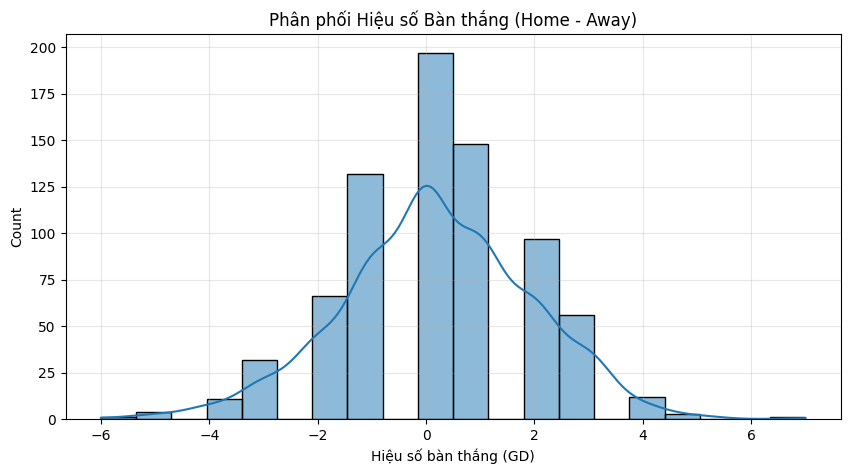

In [54]:
# Xem độ lệch bàn thắng (target) giữa đội nhà và đội khách
if 'df_ml' in locals():
    plt.figure(figsize=(10, 5))
    sns.histplot(df_ml['target_home_goals'] - df_ml['target_away_goals'], bins=20, kde=True)
    plt.title('Phân phối Hiệu số Bàn thắng (Home - Away)')
    plt.xlabel('Hiệu số bàn thắng (GD)')
    plt.grid(alpha=0.3)
    plt.show()


/tmp/ipykernel_19516/1942038594.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ml, x='target', y='elo_diff', order=['A', 'D', 'H'], palette='viridis')


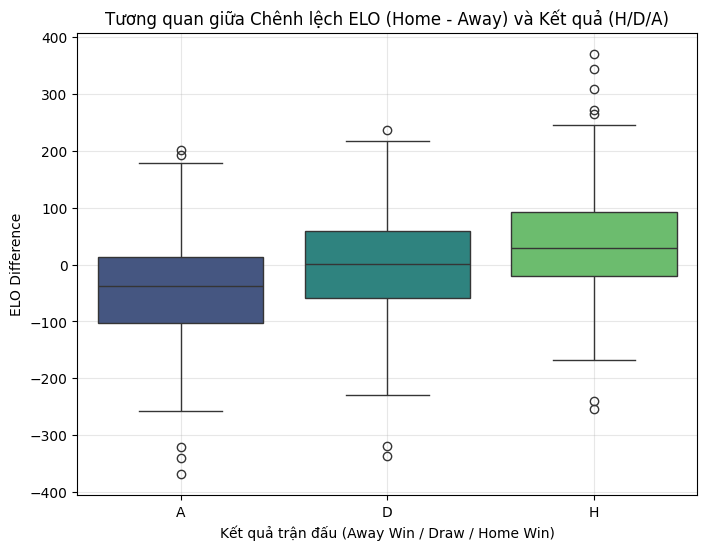

In [55]:
# Tương quan giữa ELO chênh lệch và Kết quả trận đấu
if 'df_ml' in locals():
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_ml, x='target', y='elo_diff', order=['A', 'D', 'H'], palette='viridis')
    plt.title('Tương quan giữa Chênh lệch ELO (Home - Away) và Kết quả (H/D/A)')
    plt.xlabel('Kết quả trận đấu (Away Win / Draw / Home Win)')
    plt.ylabel('ELO Difference')
    plt.grid(alpha=0.3)
    plt.show()


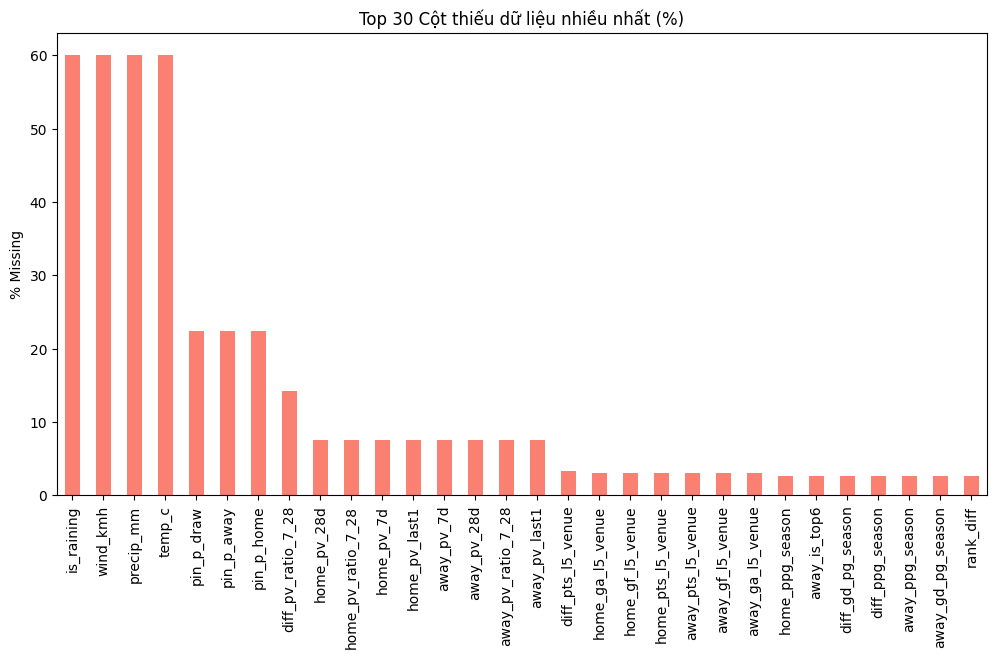

In [56]:
# Kiểm tra Missing Values của các nhóm Features
if 'df_ml' in locals():
    missing = df_ml.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False) / len(df_ml) * 100
    if len(missing) > 0:
        plt.figure(figsize=(12, 6))
        missing[:30].plot(kind='bar', color='salmon')
        plt.title('Top 30 Cột thiếu dữ liệu nhiều nhất (%)')
        plt.ylabel('% Missing')
        plt.show()
    else:
        print('Dữ liệu siêu sạch, không có cột nào bị Missing Values!')


/tmp/ipykernel_19516/2399843267.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rate = df_ml[df_ml['target'] == 'H'].groupby('odds_bin').size() / df_ml.groupby('odds_bin').size()
/tmp/ipykernel_19516/2399843267.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rate = df_ml[df_ml['target'] == 'H'].groupby('odds_bin').size() / df_ml.groupby('odds_bin').size()
/tmp/ipykernel_19516/2399843267.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wi

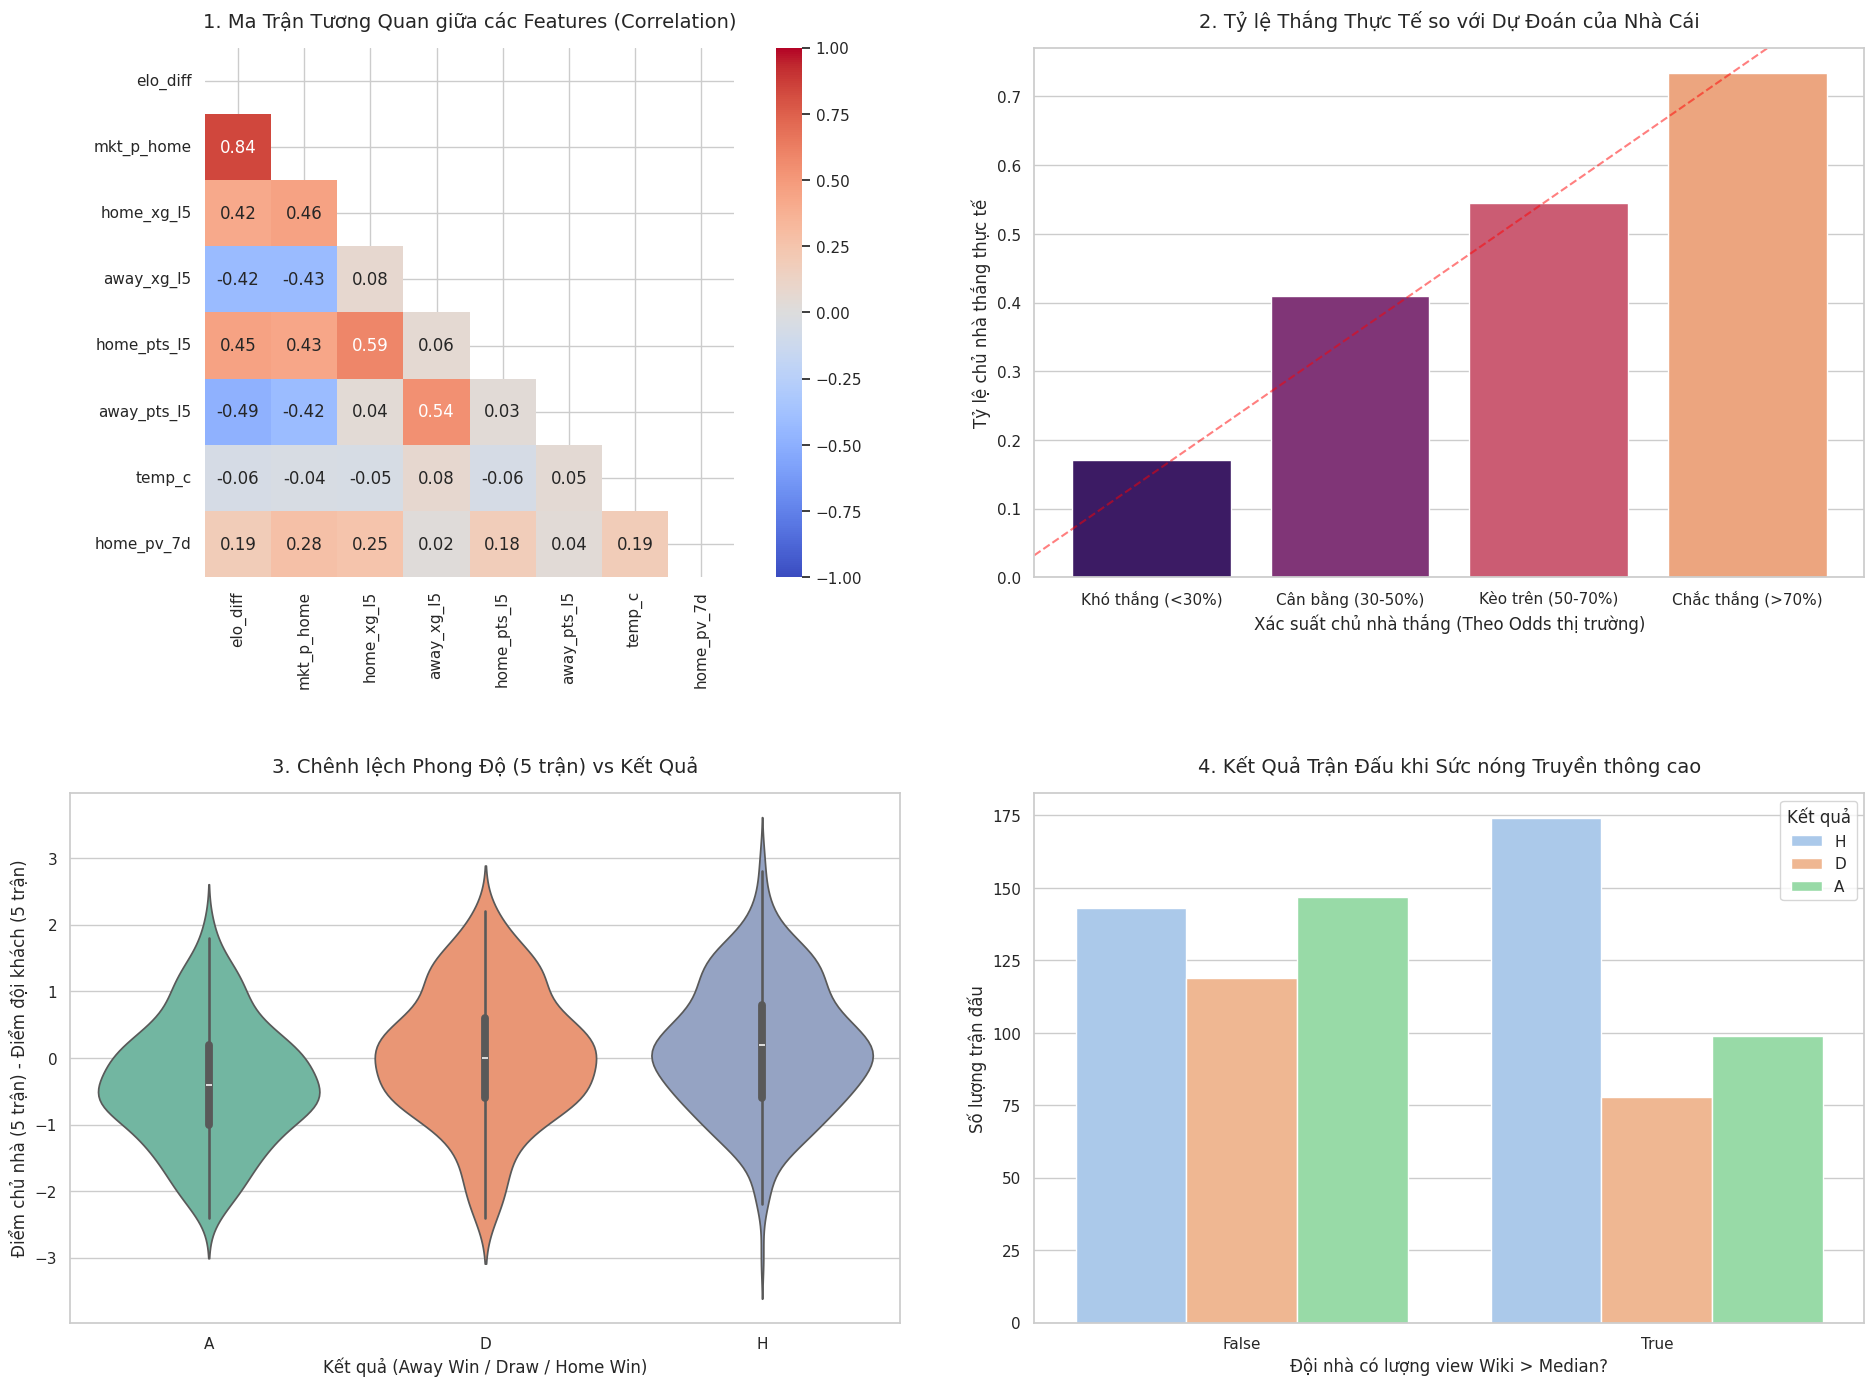

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if 'df_ml' in locals():
    # Cài đặt phong cách đồ thị
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(20, 15))
    
    # ---------------------------------------------------------
    # 1. BIỂU ĐỒ TƯƠNG QUAN (CORRELATION MATRIX)
    # ---------------------------------------------------------
    plt.subplot(2, 2, 1)
    numeric_cols = ['elo_diff', 'mkt_p_home', 'home_xg_l5', 'away_xg_l5', 
                    'home_pts_l5', 'away_pts_l5', 'temp_c', 'home_pv_7d']
    valid_cols = [c for c in numeric_cols if c in df_ml.columns]
    
    corr = df_ml[valid_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
    plt.title('1. Ma Trận Tương Quan giữa các Features (Correlation)', fontsize=14, pad=15)
    
    # ---------------------------------------------------------
    # 2. ĐỘ CHÍNH XÁC CỦA NHÀ CÁI (ODDS vs THỰC TẾ)
    # ---------------------------------------------------------
    plt.subplot(2, 2, 2)
    if 'mkt_p_home' in df_ml.columns:
        # Chia khoảng xác suất nhà cái: <30%, 30-50%, 50-70%, >70%
        df_ml['odds_bin'] = pd.cut(df_ml['mkt_p_home'], bins=[0, 0.3, 0.5, 0.7, 1.0], 
                                   labels=['Khó thắng (<30%)', 'Cân bằng (30-50%)', 'Kèo trên (50-70%)', 'Chắc thắng (>70%)'])
        win_rate = df_ml[df_ml['target'] == 'H'].groupby('odds_bin').size() / df_ml.groupby('odds_bin').size()
        
        sns.barplot(x=win_rate.index, y=win_rate.values, palette='magma')
        plt.axline((0, 0.15), slope=0.2, color='red', linestyle='--', alpha=0.5, label='Đường lý tưởng')
        plt.title('2. Tỷ lệ Thắng Thực Tế so với Dự Đoán của Nhà Cái', fontsize=14, pad=15)
        plt.ylabel('Tỷ lệ chủ nhà thắng thực tế')
        plt.xlabel('Xác suất chủ nhà thắng (Theo Odds thị trường)')
    
    # ---------------------------------------------------------
    # 3. ẢNH HƯỞNG CỦA PHONG ĐỘ (FORM)
    # ---------------------------------------------------------
    plt.subplot(2, 2, 3)
    if 'home_pts_l5' in df_ml.columns and 'away_pts_l5' in df_ml.columns:
        df_ml['form_diff'] = df_ml['home_pts_l5'] - df_ml['away_pts_l5']
        sns.violinplot(data=df_ml, x='target', y='form_diff', order=['A', 'D', 'H'], palette='Set2')
        plt.title('3. Chênh lệch Phong Độ (5 trận) vs Kết Quả', fontsize=14, pad=15)
        plt.xlabel('Kết quả (Away Win / Draw / Home Win)')
        plt.ylabel('Điểm chủ nhà (5 trận) - Điểm đội khách (5 trận)')

    # ---------------------------------------------------------
    # 4. SỨC NÓNG TRUYỀN THÔNG CÓ GÂY ÁP LỰC? (PAGEVIEWS)
    # ---------------------------------------------------------
    plt.subplot(2, 2, 4)
    if 'home_pv_7d' in df_ml.columns:
        df_ml['is_big_match'] = df_ml['home_pv_7d'] > df_ml['home_pv_7d'].median()
        sns.countplot(data=df_ml, x='is_big_match', hue='target', hue_order=['H', 'D', 'A'], palette='pastel')
        plt.title('4. Kết Quả Trận Đấu khi Sức nóng Truyền thông cao', fontsize=14, pad=15)
        plt.xlabel('Đội nhà có lượng view Wiki > Median?')
        plt.ylabel('Số lượng trận đấu')
        plt.legend(title='Kết quả')

    plt.tight_layout(pad=4.0)
    plt.show()


/tmp/ipykernel_19516/407226931.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ml, x='temp_bin', y='target_total_goals', palette='coolwarm')


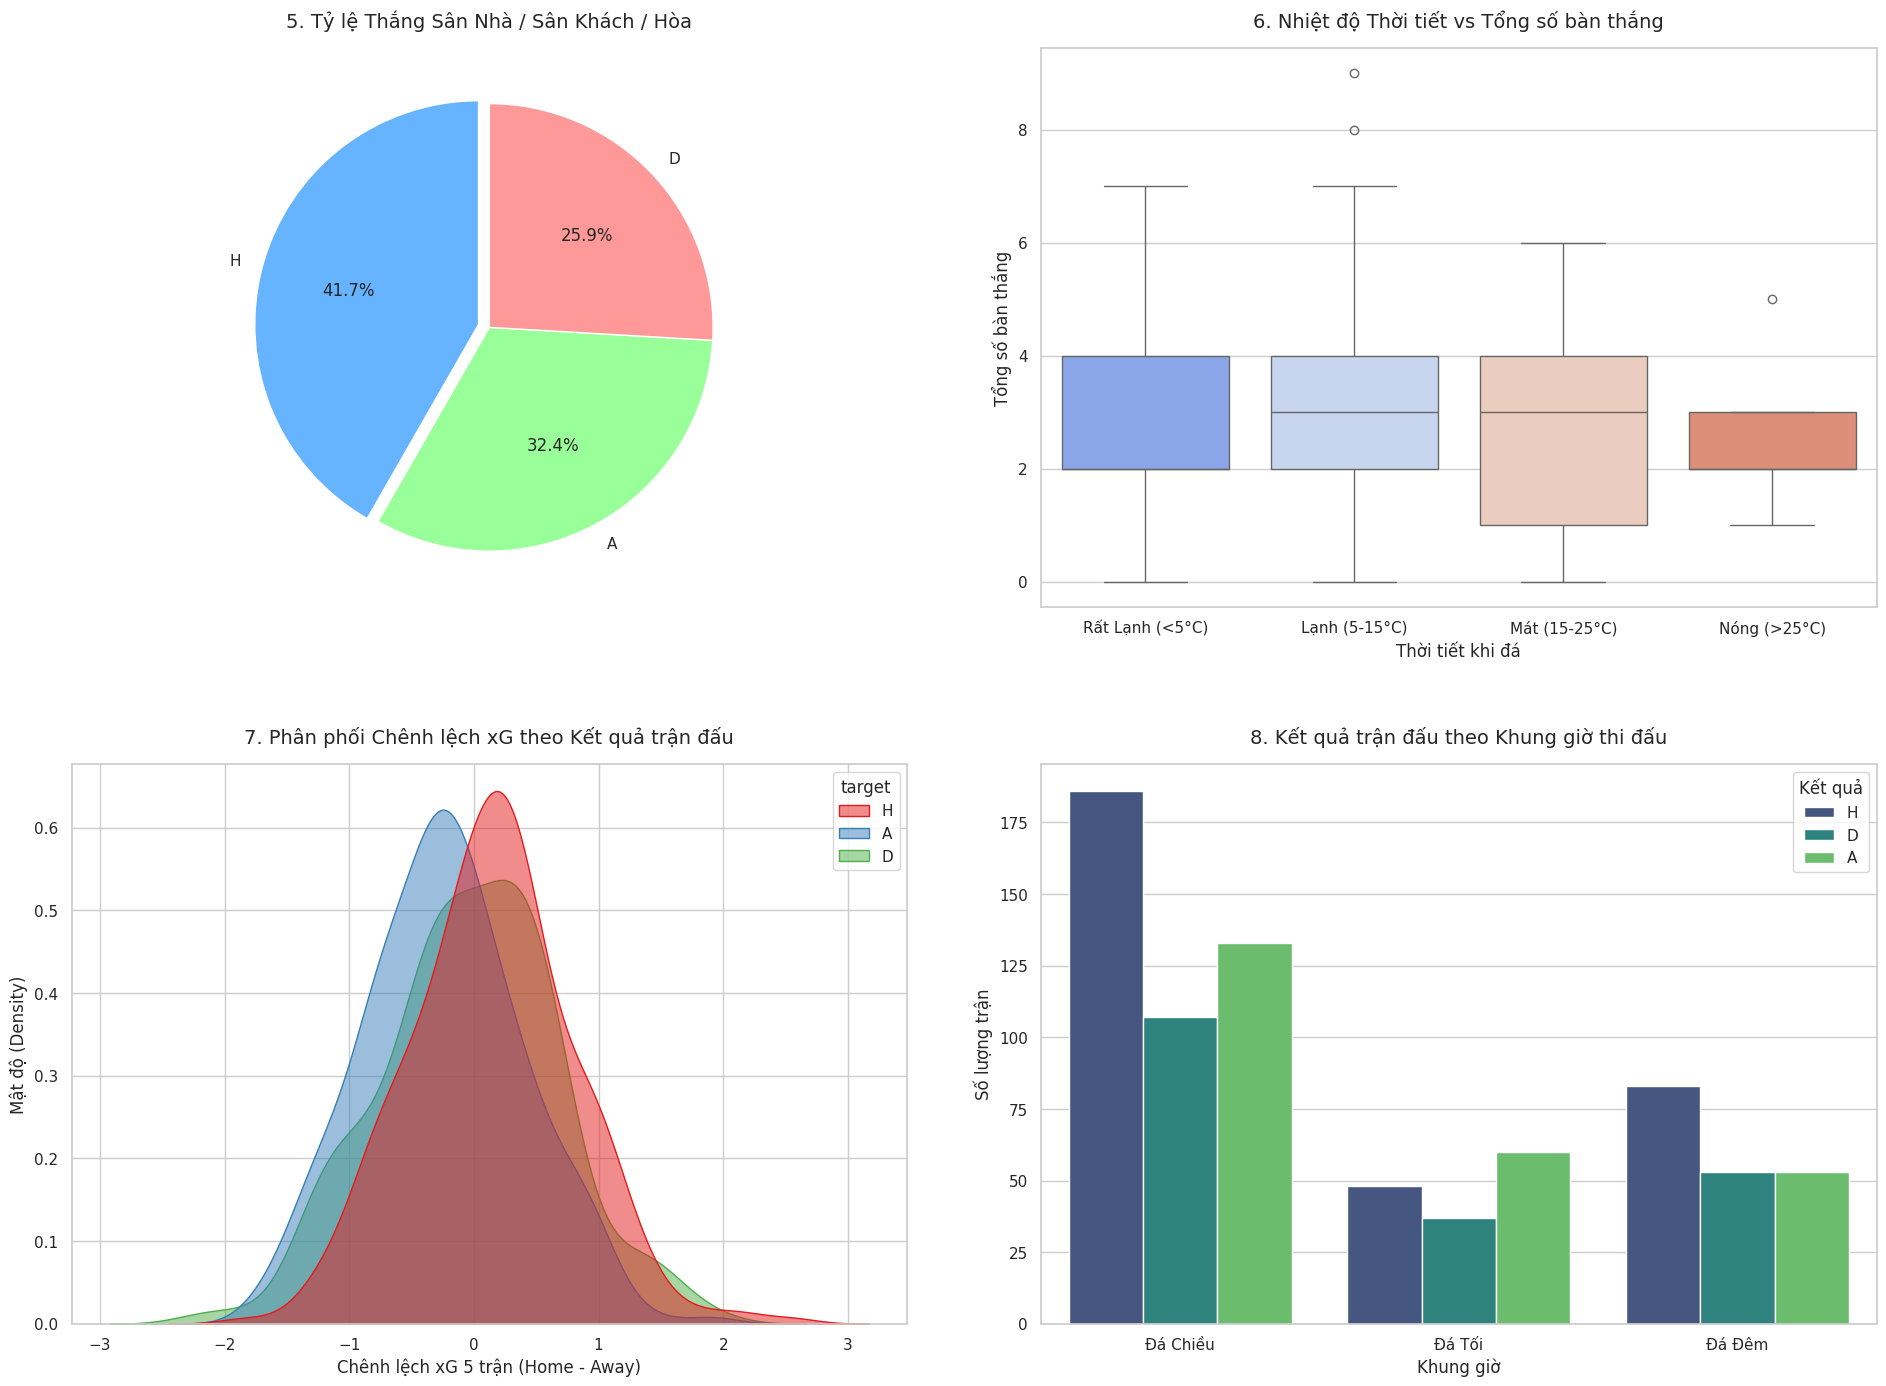

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

if 'df_ml' in locals():
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(20, 15))
    
    # ---------------------------------------------------------
    # 5. PHÂN BỐ KẾT QUẢ TRẬN ĐẤU (CLASS IMBALANCE)
    # ---------------------------------------------------------
    # Ngoại hạng Anh nổi tiếng với Lợi thế sân nhà. Hãy xem tỷ lệ chính xác là bao nhiêu.
    plt.subplot(2, 2, 1)
    result_counts = df_ml['target'].value_counts()
    plt.pie(result_counts, labels=result_counts.index, autopct='%1.1f%%', 
            colors=['#66b3ff', '#99ff99', '#ff9999'], startangle=90, explode=(0.05, 0, 0))
    plt.title('5. Tỷ lệ Thắng Sân Nhà / Sân Khách / Hòa', fontsize=14, pad=15)
    
    # ---------------------------------------------------------
    # 6. THỜI TIẾT CÓ LÀM GIẢM SỐ BÀN THẮNG?
    # ---------------------------------------------------------
    # Khi trời mưa hoặc lạnh, cầu thủ có ghi ít bàn hơn không?
    plt.subplot(2, 2, 2)
    if 'temp_c' in df_ml.columns and 'target_total_goals' in df_ml.columns:
        # Cắt nhiệt độ thành các khoảng
        df_ml['temp_bin'] = pd.cut(df_ml['temp_c'], bins=[-10, 5, 15, 25, 40], 
                                   labels=['Rất Lạnh (<5°C)', 'Lạnh (5-15°C)', 'Mát (15-25°C)', 'Nóng (>25°C)'])
        sns.boxplot(data=df_ml, x='temp_bin', y='target_total_goals', palette='coolwarm')
        plt.title('6. Nhiệt độ Thời tiết vs Tổng số bàn thắng', fontsize=14, pad=15)
        plt.xlabel('Thời tiết khi đá')
        plt.ylabel('Tổng số bàn thắng')
    
    # ---------------------------------------------------------
    # 7. SỨC MẠNH TẤN CÔNG (xG) CHI PHỐI KẾT QUẢ THẾ NÀO?
    # ---------------------------------------------------------
    # Chênh lệch Kỳ vọng bàn thắng 5 trận gần nhất
    plt.subplot(2, 2, 3)
    if 'home_xg_l5' in df_ml.columns and 'away_xg_l5' in df_ml.columns:
        df_ml['xg_diff'] = df_ml['home_xg_l5'] - df_ml['away_xg_l5']
        sns.kdeplot(data=df_ml, x='xg_diff', hue='target', fill=True, common_norm=False, palette='Set1', alpha=0.5)
        plt.title('7. Phân phối Chênh lệch xG theo Kết quả trận đấu', fontsize=14, pad=15)
        plt.xlabel('Chênh lệch xG 5 trận (Home - Away)')
        plt.ylabel('Mật độ (Density)')
        
    # ---------------------------------------------------------
    # 8. GIỜ VÀNG VÀ CUỐI TUẦN
    # ---------------------------------------------------------
    # Đá vào cuối tuần hay đá khung giờ tối có nhiều bất ngờ (Khách thắng) hơn không?
    plt.subplot(2, 2, 4)
    if 'is_weekend' in df_ml.columns and 'kickoff_hour' in df_ml.columns:
        # Nhóm giờ đá: Trước 16h (Chiều), 16h-19h (Tối), Sau 19h (Đêm)
        df_ml['time_slot'] = pd.cut(df_ml['kickoff_hour'], bins=[0, 15, 18, 24], 
                                    labels=['Đá Chiều', 'Đá Tối', 'Đá Đêm'])
        sns.countplot(data=df_ml, x='time_slot', hue='target', hue_order=['H', 'D', 'A'], palette='viridis')
        plt.title('8. Kết quả trận đấu theo Khung giờ thi đấu', fontsize=14, pad=15)
        plt.xlabel('Khung giờ')
        plt.ylabel('Số lượng trận')
        plt.legend(title='Kết quả')

    plt.tight_layout(pad=4.0)
    plt.show()


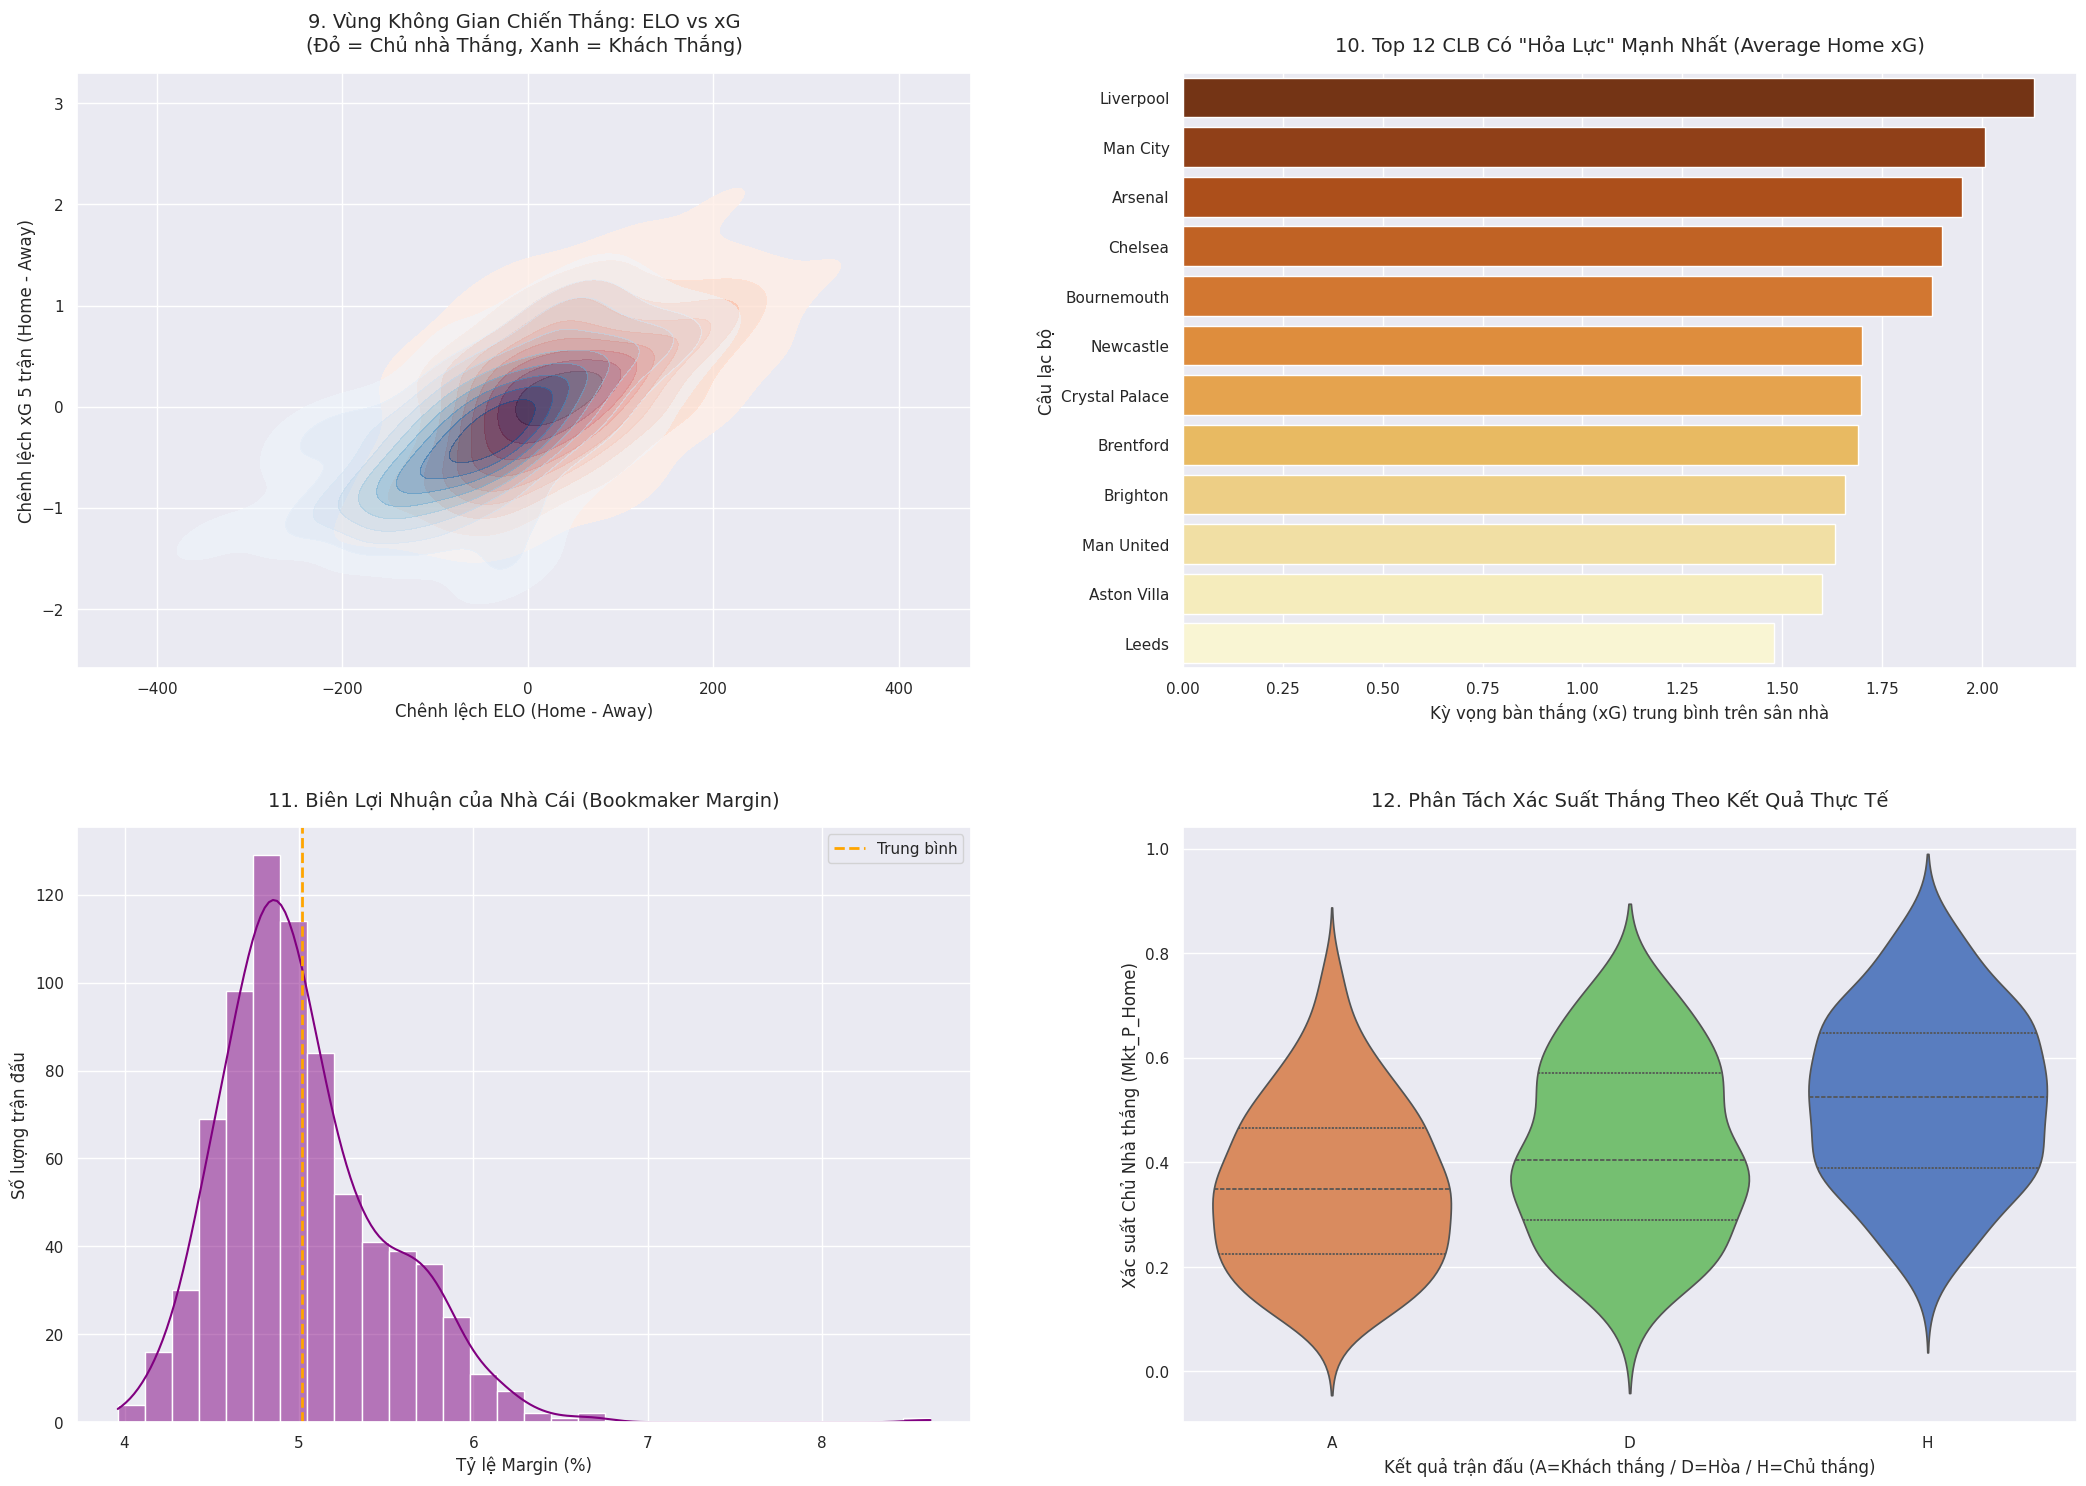

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

if 'df_ml' in locals():
    sns.set_theme(style="darkgrid")
    fig = plt.figure(figsize=(22, 16))
    
    # Tạo thêm biến Chênh lệch xG nếu chưa có
    if 'xg_diff' not in df_ml.columns and 'home_xg_l5' in df_ml.columns:
        df_ml['xg_diff'] = df_ml['home_xg_l5'] - df_ml['away_xg_l5']

    # ---------------------------------------------------------
    # 9. BẢN ĐỒ NHIỆT ĐA BIẾN (2D CONTOUR PLOT) 
    # ---------------------------------------------------------
    plt.subplot(2, 2, 1)
    if 'elo_diff' in df_ml.columns and 'xg_diff' in df_ml.columns:
        sns.kdeplot(
            data=df_ml[df_ml['target'] == 'H'], 
            x='elo_diff', y='xg_diff', 
            fill=True, cmap="Reds", thresh=0.05, alpha=0.8
        )
        sns.kdeplot(
            data=df_ml[df_ml['target'] == 'A'], 
            x='elo_diff', y='xg_diff', 
            fill=True, cmap="Blues", thresh=0.05, alpha=0.5
        )
        plt.title('9. Vùng Không Gian Chiến Thắng: ELO vs xG\n(Đỏ = Chủ nhà Thắng, Xanh = Khách Thắng)', fontsize=14, pad=15)
        plt.xlabel('Chênh lệch ELO (Home - Away)')
        plt.ylabel('Chênh lệch xG 5 trận (Home - Away)')
        
    # ---------------------------------------------------------
    # 10. BẢNG XẾP HẠNG HỎA LỰC TẤN CÔNG (TOP 12 TEAMS)
    # ---------------------------------------------------------
    plt.subplot(2, 2, 2)
    if 'home_xg_l5' in df_ml.columns and 'home_team' in df_ml.columns:
        top_attack = df_ml.groupby('home_team')['home_xg_l5'].mean().sort_values(ascending=False).head(12)
        # Sửa lỗi: Thêm hue và legend=False
        sns.barplot(x=top_attack.values, y=top_attack.index, hue=top_attack.index, palette="YlOrBr_r", legend=False)
        plt.title('10. Top 12 CLB Có "Hỏa Lực" Mạnh Nhất (Average Home xG)', fontsize=14, pad=15)
        plt.xlabel('Kỳ vọng bàn thắng (xG) trung bình trên sân nhà')
        plt.ylabel('Câu lạc bộ')
        
    # ---------------------------------------------------------
    # 11. BÍ MẬT CỦA NHÀ CÁI (BOOKMAKER MARGIN)
    # ---------------------------------------------------------
    plt.subplot(2, 2, 3)
    if 'mkt_margin' in df_ml.columns:
        sns.histplot(df_ml['mkt_margin'] * 100, bins=30, color='purple', kde=True)
        plt.axvline((df_ml['mkt_margin'] * 100).mean(), color='orange', linestyle='dashed', linewidth=2, label='Trung bình')
        plt.title('11. Biên Lợi Nhuận của Nhà Cái (Bookmaker Margin)', fontsize=14, pad=15)
        plt.xlabel('Tỷ lệ Margin (%)')
        plt.ylabel('Số lượng trận đấu')
        plt.legend()

    # ---------------------------------------------------------
    # 12. PHÂN TÁCH BIẾN BẰNG VIOLIN PLOT (FEATURES SEPARATION)
    # ---------------------------------------------------------
    plt.subplot(2, 2, 4)
    if 'mkt_p_home' in df_ml.columns:
        # Sửa lỗi: Đổi palette='muted', thêm hue='target', legend=False
        sns.violinplot(data=df_ml, x='target', y='mkt_p_home', order=['A', 'D', 'H'], 
                       hue='target', palette='muted', inner="quartile", legend=False)
        plt.title('12. Phân Tách Xác Suất Thắng Theo Kết Quả Thực Tế', fontsize=14, pad=15)
        plt.xlabel('Kết quả trận đấu (A=Khách thắng / D=Hòa / H=Chủ thắng)')
        plt.ylabel('Xác suất Chủ Nhà thắng (Mkt_P_Home)')

    plt.tight_layout(pad=4.0)
    plt.show()


Đang tải dữ liệu từ MinIO...
Tải thành công! Bắt đầu vẽ biểu đồ...


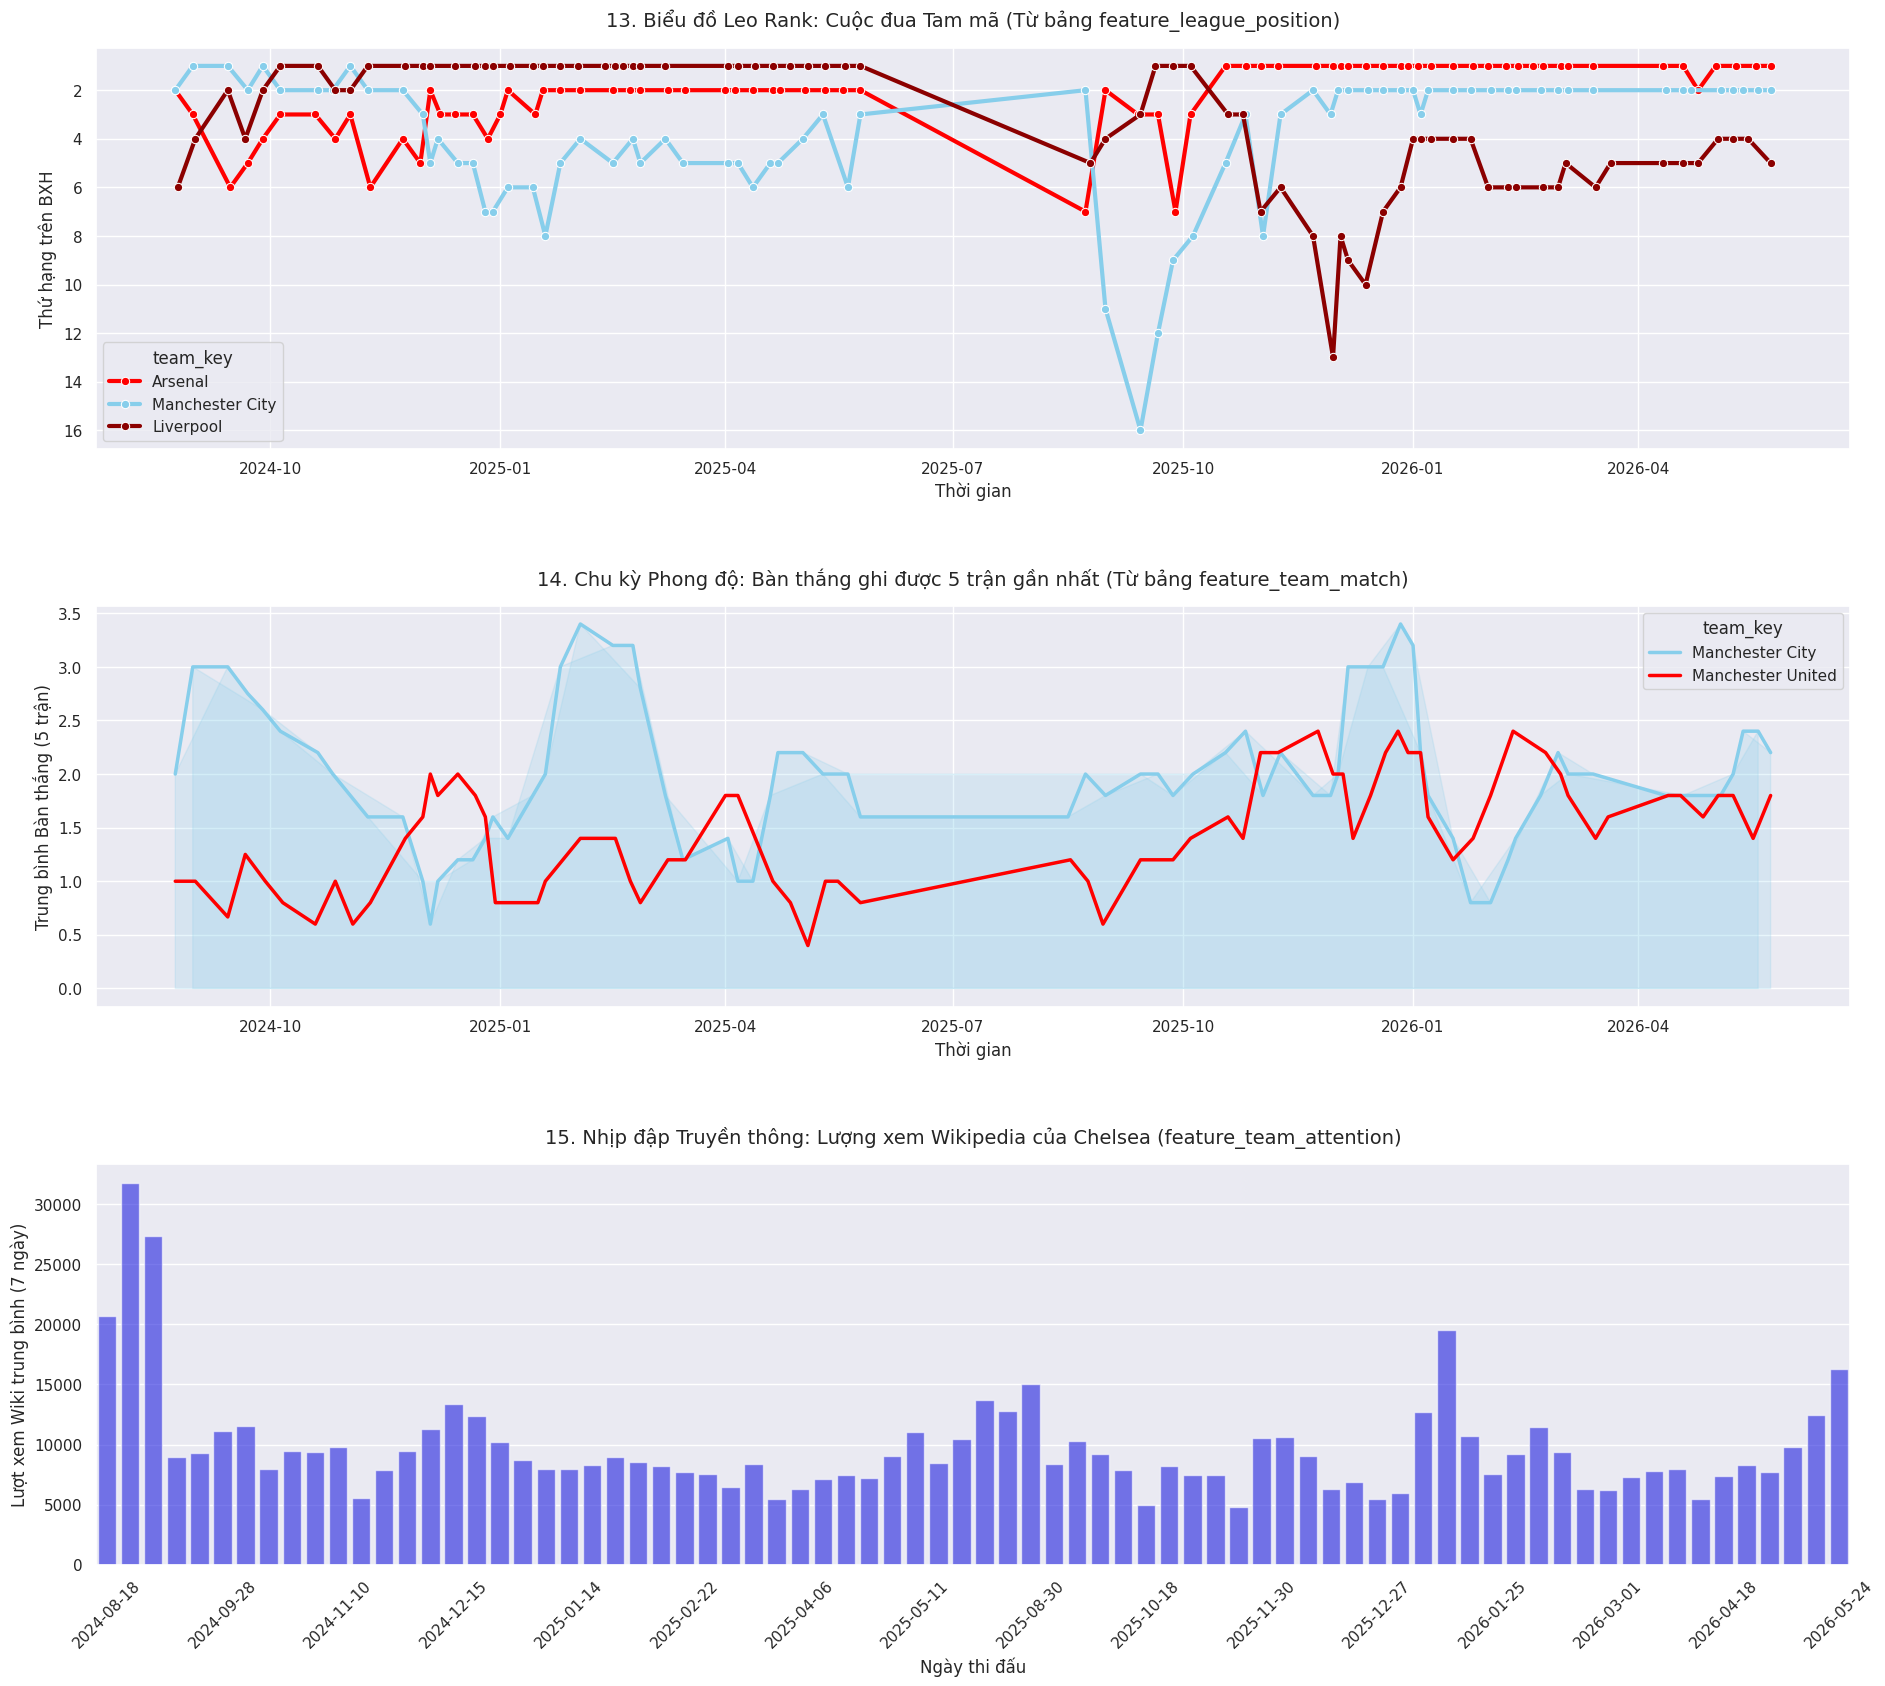

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import io
from lake import minio_io as mio

try:
    sns.set_theme(style="darkgrid")
    fig = plt.figure(figsize=(20, 18))
    
    # Đọc 3 bảng thành phần từ Data Lake (MinIO)
    print("Đang tải dữ liệu từ MinIO...")
    df_pos = pd.read_parquet(io.BytesIO(mio.read_bytes('gold/features/feature_league_position.parquet')))
    df_form = pd.read_parquet(io.BytesIO(mio.read_bytes('gold/features/feature_team_match.parquet')))
    df_att = pd.read_parquet(io.BytesIO(mio.read_bytes('gold/features/feature_team_attention.parquet')))
    print("Tải thành công! Bắt đầu vẽ biểu đồ...")
    
    # Lấy thông tin ngày tháng từ df_ml
    match_info = df_ml[['match_id', 'match_date']].drop_duplicates()
    
    # Hàm ghép ngày tháng an toàn (nếu bảng chưa có match_date thì mới ghép)
    def add_date(df):
        if 'match_date' not in df.columns:
            return df.merge(match_info, on='match_id', how='left')
        return df

    df_pos = add_date(df_pos)
    df_form = add_date(df_form)
    df_att = add_date(df_att)
    
    # ---------------------------------------------------------
    # 13. CUỘC ĐUA VÔ ĐỊCH (POSITION TRACKER)
    # ---------------------------------------------------------
    plt.subplot(3, 1, 1)
    df_race = df_pos[df_pos['team_key'].isin(['Arsenal', 'Manchester City', 'Liverpool'])]
    
    if not df_race.empty:
        sns.lineplot(data=df_race, x='match_date', y='rank_before', hue='team_key', 
                     palette={'Arsenal':'red', 'Manchester City':'skyblue', 'Liverpool':'darkred'}, 
                     linewidth=3, marker='o')
        plt.gca().invert_yaxis() # Đảo ngược trục Y vì Hạng 1 nằm ở trên cùng
        plt.title('13. Biểu đồ Leo Rank: Cuộc đua Tam mã (Từ bảng feature_league_position)', fontsize=14, pad=15)
        plt.ylabel('Thứ hạng trên BXH')
        plt.xlabel('Thời gian')
    
    # ---------------------------------------------------------
    # 14. BIỂU ĐỒ HÌNH SIN CỦA PHONG ĐỘ (FORM TRACKER)
    # ---------------------------------------------------------
    plt.subplot(3, 1, 2)
    df_form_filtered = df_form[df_form['team_key'].isin(['Manchester United', 'Manchester City'])]
    
    if not df_form_filtered.empty:
        sns.lineplot(data=df_form_filtered, x='match_date', y='gf_l5', hue='team_key', 
                     palette={'Manchester United':'red', 'Manchester City':'skyblue'}, linewidth=2.5)
        plt.fill_between(df_form_filtered[df_form_filtered['team_key']=='Manchester City']['match_date'], 
                         df_form_filtered[df_form_filtered['team_key']=='Manchester City']['gf_l5'], color="skyblue", alpha=0.2)
        plt.title('14. Chu kỳ Phong độ: Bàn thắng ghi được 5 trận gần nhất (Từ bảng feature_team_match)', fontsize=14, pad=15)
        plt.ylabel('Trung bình Bàn thắng (5 trận)')
        plt.xlabel('Thời gian')

    # ---------------------------------------------------------
    # 15. SỰ CHÚ Ý CỦA TRUYỀN THÔNG (ATTENTION SPIKES)
    # ---------------------------------------------------------
    plt.subplot(3, 1, 3)
    df_chelsea_att = df_att[df_att['team_key'] == 'Chelsea'].sort_values('match_date')
    
    if not df_chelsea_att.empty:
        sns.barplot(data=df_chelsea_att, x='match_date', y='pv_7d', color='blue', alpha=0.6)
        plt.xticks(range(0, len(df_chelsea_att), 5), df_chelsea_att['match_date'].iloc[::5].astype(str), rotation=45)
        plt.title('15. Nhịp đập Truyền thông: Lượng xem Wikipedia của Chelsea (feature_team_attention)', fontsize=14, pad=15)
        plt.ylabel('Lượt xem Wiki trung bình (7 ngày)')
        plt.xlabel('Ngày thi đấu')

    plt.tight_layout(pad=4.0)
    plt.show()

except Exception as e:
    print('Lỗi:', e)


Đang tải dữ liệu YouTube từ lớp SILVER (Chuẩn Data Warehouse)...
✅ Tải thành công 15182 bình luận và 100 videos từ lớp Silver!

🔥 TOP 5 BÌNH LUẬN ĐƯỢC NHIỀU LIKE NHẤT:
👤 @JjX-r3i (1291 likes): Max took that ball away from Gyokeres and said gimme dat, the confidence is off the roof from this lad 🔥🔥...
👤 @edoson1234 (921 likes): zion suzuki is the best signing this season what a great goal keeper...
👤 @Laviranatos (770 likes): Well on the bright side, we didn’t give Spurs their first goal of the season 😅 Really wished we would have won this one though, even had a Stake bet o...
👤 @mattyice2367 (711 likes): My real Arsenal fans clapped when Akpom scored...
👤 @astakym (655 likes): Congrats, Brentford. Sangaré knew he was good at Lens. What a player!...


/tmp/ipykernel_19516/3032603329.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_words, x='Tần suất', y='Từ khóa', palette='viridis')


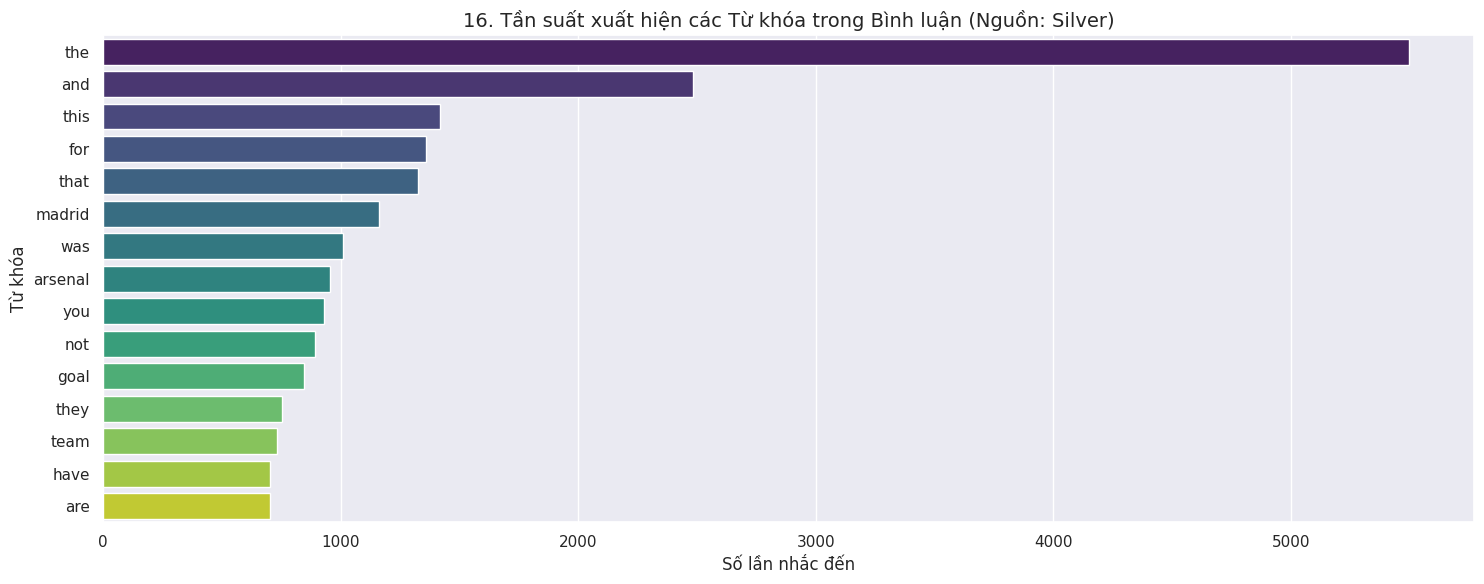

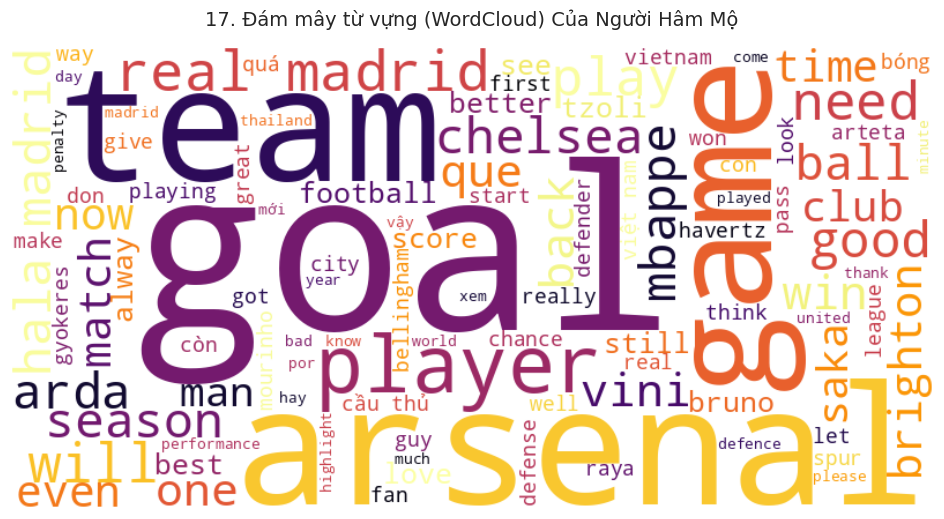

In [71]:
import pandas as pd
import io
from lake import minio_io as mio
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

try:
    print("Đang tải dữ liệu YouTube từ lớp SILVER (Chuẩn Data Warehouse)...")
    
    # 1. ĐỌC DỮ LIỆU TỪ LỚP SILVER (Dạng Parquet Tốc độ cao)
    keys_c = [k[0] for k in mio.list_keys("silver/text/youtube_comments/")]
    keys_v = [k[0] for k in mio.list_keys("silver/text/youtube_videos/")]
    
    df_cmt = pd.concat([pd.read_parquet(io.BytesIO(mio.read_bytes(k))) for k in keys_c if k.endswith('.parquet')])
    df_vid = pd.concat([pd.read_parquet(io.BytesIO(mio.read_bytes(k))) for k in keys_v if k.endswith('.parquet')])
    
    print(f"✅ Tải thành công {len(df_cmt)} bình luận và {len(df_vid)} videos từ lớp Silver!\n")
    
    # ---------------------------------------------------------
    # 16. NHỮNG BÌNH LUẬN "BÃO LIKE" NHẤT (TOP COMMENTS)
    # ---------------------------------------------------------
    print("🔥 TOP 5 BÌNH LUẬN ĐƯỢC NHIỀU LIKE NHẤT:")
    top_cmts = df_cmt.sort_values(by='like_count', ascending=False).head(5)
    for i, row in top_cmts.iterrows():
        print(f"👤 {row['author']} ({int(row['like_count'])} likes): {str(row['text'])[:150]}...")
        
    # ---------------------------------------------------------
    # 17. PHÂN TÍCH TỪ KHÓA (KEYWORD ANALYSIS)
    # ---------------------------------------------------------
    fig = plt.figure(figsize=(15, 6))
    
    # Dữ liệu Silver đã được làm sạch link web, giờ ta chỉ tách từ
    all_text = " ".join(df_cmt['text'].astype(str).tolist()).lower()
    words = re.findall(r'\b[a-zà-ỹ]+\b', all_text)
    
    # Từ khóa vô nghĩa cần loại bỏ
    stop_words = {'và', 'của', 'là', 'có', 'trong', 'những', 'để', 'không', 'được', 'một', 
                  'thì', 'mà', 'với', 'cho', 'này', 'cũng', 'đã', 'người', 'cái', 'các',
                  'br', 'nó', 'rồi', 'đến', 'lại', 'vào', 'bị', 'như', 'khi', 'chỉ', 'nhiều'}
    clean_words = [w for w in words if w not in stop_words and len(w) > 2]
    
    word_counts = Counter(clean_words).most_common(15)
    df_words = pd.DataFrame(word_counts, columns=['Từ khóa', 'Tần suất'])
    
    sns.barplot(data=df_words, x='Tần suất', y='Từ khóa', palette='viridis')
    plt.title('16. Tần suất xuất hiện các Từ khóa trong Bình luận (Nguồn: Silver)', fontsize=14)
    plt.xlabel('Số lần nhắc đến')
    plt.ylabel('Từ khóa')
    plt.tight_layout()
    plt.show()
    
    # ---------------------------------------------------------
    # 18. WORDCLOUD (ĐÁM MÂY TỪ VỰNG) 
    # ---------------------------------------------------------
    try:
        from wordcloud import WordCloud
        wordcloud = WordCloud(width=800, height=400, background_color='white', 
                              colormap='inferno', max_words=100).generate(" ".join(clean_words))
        plt.figure(figsize=(12, 6))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title('17. Đám mây từ vựng (WordCloud) Của Người Hâm Mộ', fontsize=14, pad=15)
        plt.show()
    except ImportError:
        print("\n💡 Gợi ý: Hãy cài thư viện wordcloud (!pip install wordcloud) để xem biểu đồ Đám mây!")

except Exception as e:
    print('Lỗi quá trình tải:', e)
